<div style="border:solid Green 2px; border-radius: 10px;  padding: 40px">
<b>Привет, Михаил!👋</b>
    
Меня зовут Зуева Юлия, можно просто Юля 😏 Я буду ревьюером твоего проекта. Предлагаю обращаться на "ты", но если это неудобно, пожалуйста, скажи об этом! 
    
Моя основная цель - помочь тебе стать компетентным Data Scientist'ом: вместе преодолеть трудности и еще больше развить твои сильные навыки 💪 В твоей работе я оставила комментарии, которые должны в этом помочь. Для твоего удобства комментарии раскрашены разными цветами: 
<br/>
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> В случае корректного решения (или отдельных его моментов). На такие решения можно опираться в будущем.
</div>
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> Если есть возможность как-либо улучшить решение. Ты можешь учесть эти комментарии при доработке проекта, однако для зачета это не обязательно.
</div>
<div style="border-radius: 10px" class="alert alert-block alert-danger">
<b>Нужно доработать ❌:</b> Если решение требует внесения правок. Проект не может быть принят, если остались не отработанные комментарии данного типа.
</div>

Чтобы наша с тобой работа была еще эффективнее, ты точно так же можешь оставлять комментарии и задавать мне вопросы. Для таких случаев, пожалуйста, выбери собственное оформление комментариев, которое будет отличаться от моего, чтобы не создавалась путаница. По этой же причине попрошу тебя не удалять и не изменять мои комментарии. Все это позволит лучше ориентироваться в нашем с тобой диалоге, а повторную проверку (в случае ее необходимости) выполнять оперативнее 🚀
    
Не спеши расстраиваться, если что-то не удалось с первого раза. Вместе мы обязательно разберемся со всеми трудностями! 🤓


<div style="border:solid Blue 2px; border-radius: 10px;  padding: 40px">
<b>Привет, Юлия!</b>

Спасибо за проверку моего проекта. Я свои комментарию буду оформлять в таком ввиде:
<br><div style="border-radius: 10px" class="alert alert-info"> <b>Комментарий студента v1:</b>
<br>Комментарий 
</div>

# 🏦 Поведенческий скоринг: Прогнозирование дефолтов клиентов банка

Автор: Якунин Михаил

Дата: 10 июля 2026 г.

***По этой ссылке можно посмотреть проекта и скачать последнюю версию: https://github.com/MEYakunin/Sprint15_User_Behavior_Scoring.git***

## Цель проекта

**Бизнес-цель:** 
Разработать модель поведенческого скоринга для розничного банка «Ва-банк», чтобы заранее выявлять рост кредитного риска у действующих клиентов. Точный прогноз просрочек позволит банку не создавать избыточные резервы под возможные потери, увеличить объем свободных средств в обороте на 5–10% и эффективно управлять ликвидностью («нет сюрпризов — нет оттока вкладов»).

**Цель с точки зрения машинного обучения:** 
Построить модель бинарной классификации, которая на основе истории транзакций (MCC-коды), социально-демографических профилей, кредитных рейтингов и макроэкономических показателей прогнозирует вероятность дефолта клиента.

**Постановка задачи (ML):**
* **Объект:** Действующий клиент банка в конкретный месяц наблюдения.
* **Целевая переменная (Target):** `1` — если в ближайшие 12 месяцев у клиента возникнет просрочка 90 дней и более; `0` — если не возникнет.
* **Горизонт прогноза:** 12 месяцев (скользящее окно).

**Критерии успеха (Бизнес-метрики):**
Модель должна не просто максимизировать ROC-AUC, но и удовлетворять жестким бизнес-ограничениям при выбранном пороге классификации:
1. **Approval Rate (Уровень одобрения):** $\ge$ 65% *(банк не хочет терять прибыль, отказывая надежным клиентам)*.
2. **Default Rate (Доля дефолтов среди одобренных):** $\le$ 2% *(среди тех, кого модель пропустила, должно быть минимум проблемных)*.
3. **Missed Defaults Rate (Доля пропущенных дефолтов):** $\le$ 4% *(модель должна отлавливать большинство реальных неплательщиков)*.

## Задачи проекта

Для достижения поставленной цели необходимо последовательно решить следующие задачи:

1. **Исследовательский анализ данных (EDA) и предобработка:** 
   * Загрузить и изучить 8 таблиц с разнородными данными (транзакции, макроэкономика, кредитные рейтинги и др.).
   * Проанализировать пропуски, выбросы и распределения.
   * Корректно объединить таблицы в единый датасет, строго соблюдая временную логику, чтобы избежать утечки целевой переменной и признаков из будущего.

2. **Формирование целевой переменной и генерация признаков:**
   * Рассчитать целевую переменную по принципу скользящего окна: факт просрочки 90+ дней в горизонте 12 месяцев.
   * Создать новые осмысленные признаки (например, кредитная нагрузка, стаж клиента), которые усилят модель.
   * Проанализировать баланс классов и подготовить стратегию работы с дисбалансом.

3. **Подготовка выборок и пайплайнов:**
   * Разделить данные на обучающую, калибровочную (валидационную) и тестовую выборки с учетом временного фактора (chronological split).
   * Создать `Pipeline` для автоматизации предобработки (импутация, масштабирование, кодирование категорий).

4. **Построение и сравнение базовых моделей:**
   * Обучить базовые модели (Логистическая регрессия, Случайный лес) на несбалансированных данных.
   * Обучить модели с применением методов балансировки классов (например, `class_weight`, `SMOTE`).
   * Сравнить их качество по бизнес-метрикам (`Approval Rate`, `Default Rate`, `Missed Defaults Rate`) и ML-метрикам (`ROC-AUC`).

5. **Оптимизация финальной модели:**
   * Настроить гиперпараметры итоговой модели (`Random Forest`) с помощью библиотеки `Optuna`.
   * Использовать кросс-валидацию `GroupTimeSeriesSplit` для корректной оценки на временных рядах.
   * В качестве целевой метрики для оптимизации использовать `Missed Defaults Rate`.

6. **Калибровка вероятностей:**
   * Провести калибровку предсказанных вероятностей (например, методом Изотонической регрессии), чтобы модель адекватно оценивала реальные риски.
   * Оценить качество калибровки с помощью графика и коэффициента Бриера (Brier Score).

7. **Поиск оптимального бизнес-порога:**
   * Подобрать порог классификации на калибровочной выборке, который удовлетворяет жестким требованиям бизнеса: 
     * `Approval Rate` ≥ 65%;
     * `Default Rate` ≤ 2%;
     * `Missed Defaults Rate` ≤ 4%.

8. **Финальная оценка и интерпретация:**
   * Проверить итоговый пайплайн на отложенной тестовой выборке.
   * Проанализировать матрицу ошибок и стабильность метрик.
   * Оценить важность признаков (`feature_importances_`) и сформулировать бизнес-рекомендации для риск-менеджмента банка.

## Описание данных

Для построения модели поведенческого скоринга нам предоставлены 8 таблиц с разнородными данными. Они охватывают социально-демографические факторы, финансовое поведение, кредитную историю и внешнюю макроэкономическую среду. 

Главная особенность датасета — его **временная структура**. Данные представляют собой панель (снимки поведения клиентов в разрезе месяцев), где ключевую роль играет дата скоринга (`score_date`).

**1. Данные о просрочке платежа (`ds_15_loan_payment_credit.csv`)**
История фактов просрочек по клиентам.
* `ID` — идентификатор клиента.
* `дата_начала_периода` — дата начала периода просрочки.
* `просрочка_дней` — длительность просрочки в днях.

**2. Месячные транзакции клиента (`ds_15_transactions.csv`)**
Помесячные траты клиента в разрезе MCC-кодов (категорий merchant-to-merchant). Помогает оценить стиль потребления и финансовую дисциплину.
* `ID`, `date` — идентификатор и календарная дата (на начало месяца).
* **Категории трат (MCC-коды):**
  * `5300` — Маркетплейсы и оптовики (Ozon, Wildberries и др.).
  * `5814` / `5812` — Фастфуд / Рестораны и кафе.
  * `5411` — Супермаркеты и бакалейные магазины.
  * `3990` — Экосистема Яндекса (Такси, Афиша и др.).
  * `5722` — Бытовое оборудование и техника для дома.
  * `4900` — Жилищно-коммунальные услуги (ЖКХ).
  * `MCC_другое` — Прочие категории.

**3. Социально-демографический профиль (`ds_15_client_description.csv`)**
Статичные данные о клиенте на момент регистрации в банке.
* `ID` — идентификатор клиента.
* `возраст` — возраст клиента.
* `семейное_положение` — *разведённые / есть семья / нет семьи*.
* `наличие_иждивенцев` — бинарный признак (1 — да, 0 — нет).
* `дата_регистрации` — дата начала взаимоотношений с банком.

**4. Параметры кредита (`ds_15_credit_description.csv`)**
Финансовые параметры выданного кредита.
* `ID` — идентификатор клиента.
* `доход` — месячный доход клиента на момент взятия кредита (руб.).
* `сумма_кредита` — сумма выданного кредита (руб.).

**5. Наличие ипотеки (`ds_15_mortgage_presence.csv`)**
Данные о закредитованности и наличии тяжелого кредитного обязательства.
* `ID` — идентификатор клиента.
* `дата_открытия` — дата оформления ипотеки.
* `наличие_ипотеки` — бинарный признак (1 — да, 0 — нет).

**6. Кредитный рейтинг (`ds_15_credit_rating.csv`)**
Динамика внешнего кредитного рейтинга клиента.
* `ID` — идентификатор клиента.
* `date` — дата фиксации рейтинга из внешнего источника (БКИ).
* `кредитный_рейтинг` — числовое значение рейтинга.

**7. Макроэкономические показатели РФ (`ds_15_macro_data.csv`)**
Внешние экономические факторы, которые могут влиять на платежеспособность клиентов в целом по рынку.
* `date` — месяц и год.
* `учетная_ставка`, `уровень_безработицы`, `инфляция` — ключевые макроэкономические индикаторы (%).

**8. Сетка скоринга / Даты наблюдения (`ds_15_cohort_grid.csv`)**
Таблица-основа для формирования итоговой выборки. Задает временные точки, в которые мы оцениваем состояние клиента.
* `ID` — идентификатор клиента.
* `score_date` — дата проведения поведенческого скоринга (момент «снимка» данных).

---
💡 **Важное примечание по работе с данными:** 
Поскольку мы решаем задачу *поведенческого* скоринга, при сборке итоговой таблицы (Feature Engineering) мы должны строго соблюдать временной порядок. В качестве признаков (X) мы можем использовать информацию, доступную **строго до** даты `score_date`, а целевая переменная (Target = 1) формируется, если в окне **после** `score_date` (в горизонте 12 месяцев) у клиента возникнет просрочка 90+ дней. Это критически важно для предотвращения утечки данных из будущего (Data Leakage).

## Содержание

3. **Загрузка необходимых библиотек**
4. **Загрузка данных**
5. **Исследовательский анализ данных**
6. **Объединение таблиц**
7. **Создание новых признаков**
8. **Анализ итоговой таблицы**
9. **Моделирование**
10. **Калибровка модели и пересчёт результатов**
11. **Поиск порога решения**
12. **Анализ матрицы ошибок**
13. **Фиксирование итоговой модели**
14. **Анализ важности признаков**
15. **Выводы по проекту**

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Вводная часть <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
Здорово, что оформляешь вводную часть проекта. Она помогает быстро понять цель, контекст и структуру работы - это удобно и для тебя при возвращении к проекту спустя время, и для любого другого читателя, особенно если проект публикуется в портфолио или используется как пример практической работы. Полезно воспринимать такую тетрадку не просто как выполнение домашнего задания, а как полноценный исследовательский или аналитический проект. 
    
<br/>
    
<details> <summary> <span style='color:blue' > Что обычно отмечают во введении (тык) </span> </summary>

* название и краткое описание проблемы, которую хотим решить, бизнес-контекст;
* постановку задачи и формулирование цели исследования, ожидаемого результата и практической ценности;
* описание данных: источник, объем, период, основные особенности и ограничения;
* используемые подходы, инструменты или методы анализа;
* важные допущения, ограничения и особенности поставленной задачи;
* краткий план работы и основные этапы исследования.

</details>
    
По сути, вводная часть отвечает на несколько базовых вопросов: что мы делаем, зачем, с какими данными работаем, какими методами будем решать задачу и в каких условиях проводится анализ. Хорошо оформленное введение делает проект более цельным, профессиональным и значительно упрощает навигацию по работе.

</div>


## Загрузка необходимых библиотек

In [ ]:
# Стандартные библиотеки
import warnings

# Сторонние библиотеки
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import phik
from phik import resources, report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from mlxtend.evaluate.time_series import GroupTimeSeriesSplit
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
)
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    make_scorer,
    roc_auc_score,
)
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.frozen import FrozenEstimator

# Настройка предупреждений
warnings.filterwarnings('ignore')

# Настройка логирования Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Настройки для графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Импорты <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
Здорово, что все необходимые библиотеки подгружаешь сразу в начале проекта! Это соответствует стандартам оформления кода <a href='https://pyplanet.ru/article/pep-0008.html'>PEP 8</a>. Такой подход позволяет сразу видеть, какое окружение необходимо для запуска проекта, избежать дублирования импортов в разных частях кода, а также облегчить отладку и переносимость проекта.

</div>

<div style="border-radius: 10px" class="alert alert-warning">
    
<b>Рекомендации💡:</b> 

    
* PEP 8 рекомендует сначала подгружать стандартные python-библиотеки, затем сторонние. Но для удобства каждую их этих групп также можно структурировать по тематике. Например, библиотеки для работы с данными, для работы с графиками, для подготовки к моделированию, для моделирования, для оптимизации, метрики и т.д. Так удобнее поддерживать порядок в импортах от проекта к проекту, не подгружать лишнее.

  
* Подгружать необходимо только то, что действительно используется в проекте.

    
* Множественное импортирование обычно оформляют следующим образом для сохранения большей читаемости: 
   
```python
from sklearn.preprocessing import (
      OneHotEncoder,
      OrdinalEncoder
)
```
    
</div>

<div style="border-radius: 10px" class="alert alert-info"> <b>Комментарий студента v1:</b>
<br> Я в торопях забыл проверить импорты. Удалил не используемые библиотеки и оформил множественные импорты. И перегруппировал импорты в соответствии с PEP8.
</div>

## Загрузка данных

In [2]:
# Пути к данным
paths = {
    'loan': 'datasets\ds_15_loan_payment_credit.csv',
    'trans': 'datasets\ds_15_transactions.csv',
    'client': 'datasets\ds_15_client_description.csv',
    'credit': 'datasets\ds_15_credit_description.csv',
    'mortgage': 'datasets\ds_15_mortgage_presence.csv',
    'rating': 'datasets\ds_15_credit_rating.csv',
    'macro': 'datasets\ds_15_macro_data.csv',
    'grid': 'datasets\ds_15_cohort_grid.csv'
}

# Загрузка таблиц
df_loan = pd.read_csv(paths['loan'], parse_dates=['дата_начала_периода'])
df_trans = pd.read_csv(paths['trans'], parse_dates=['date'])
df_client = pd.read_csv(paths['client'], parse_dates=['дата_регистрации'])
df_credit = pd.read_csv(paths['credit'])
df_mortgage = pd.read_csv(paths['mortgage'], parse_dates=['дата_открытия'])
df_rating = pd.read_csv(paths['rating'], parse_dates=['date'])
df_macro = pd.read_csv(paths['macro'], parse_dates=['date'])
df_grid = pd.read_csv(paths['grid'], parse_dates=['score_date'])

print("Данные успешно загружены!")

Данные успешно загружены!


In [3]:
# Словарь с данными для удобства перебора
datasets = {
    'Просрочки': df_loan,
    'Транзакции': df_trans,
    'Клиенты': df_client,
    'Кредиты': df_credit,
    'Ипотека': df_mortgage,
    'Рейтинг': df_rating,
    'Макроэкономика': df_macro,
    'Сетка скоринга': df_grid
}

# Выводим общую информацию о датасетах
print("=" * 50)
print("ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТАХ")
print("=" * 50)

for name, df in datasets.items():
    print(f"\n📊 Таблица: {name}")
    print(f"   Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
    print(f"   Пропуски: {df.isnull().sum().sum()}")
    print(f"   Дубликаты: {df.duplicated().sum()}")
    df.info()
    print("-" * 30)

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТАХ

📊 Таблица: Просрочки
   Размер: 5500 строк, 3 столбцов
   Пропуски: 0
   Дубликаты: 0
<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   5500 non-null   str           
 1   дата_начала_периода  5500 non-null   datetime64[us]
 2   просрочка_дней       5500 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 129.0 KB
------------------------------

📊 Таблица: Транзакции
   Размер: 577494 строк, 10 столбцов
   Пропуски: 0
   Дубликаты: 0
<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ID          577494 non-null  str           
 1   date        577494 non-null  datetime64[us]
 2   MCC_5300    57

### Выводы по загрузке данных

**Качество данных**

- *Все 8 таблиц загружены успешно* без ошибок
- *Пропуски отсутствуют* во всех датасетах — данные полные.
- *Дубликаты не обнаружены* — целостность данных сохранена

*Структура данных*

| Таблица | Количество записей | Описание |
|---------|-------------------|----------|
| *Клиенты, Кредиты* | 13,500 | Основная таблица с демографическими и финансовыми характеристиками |
| *Транзакции, Рейтинг, Сетка скоринга* | 577,494 каждая | Транзакционные данные — временные ряды с ежемесячной/ежедневной детализацией по клиентам |
| *Просрочки* | 5,500 | Меньше общего числа клиентов (логично: не у всех есть просрочки) |
| *Ипотека* | 6,609 | Клиенты с ипотекой |
| *Макроэкономика* | 84 | Временной ряд макроэкономических показателей для обогащения признаков |

*Ключевые наблюдения*

- *ID клиентов* присутствует во всех таблицах как ключевой идентификатор
- *Временные метки* корректно распарсены как `datetime64`
- *Транзакции агрегированы по MCC-кодам* (категории расходов), что упрощает дальнейший анализ
- *Объем данных умеренный* — подходит для обучения моделей машинного обучения без проблем с производительностью

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Загрузка данных <a class="tocSkip"></h4>


<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

После подгрузки данных необходимо вывести `info` и несколько строк, чтобы убедиться, что выгрузка прошла корректно - использовали верный разделитель, верно распознались типы, была выбрана верная кодировка. Если все окей, фиксируем это в выводах. Уже затем идем к первичному анализу данных - проверять наличие дубликатов, пропусков, выбросов, необходимость их корректировки.

</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>
<br> Перенес блок с выводом общей информации по таблицам из раздела EDA и дополнил выводом методом <code>.info()</code>. И Составил промежуточный вывод по загруженным датасетам.
</div>

## Исследовательский анализ данных

### Детальный анализ таблицы «Просрочки» (df_loan)


=== Анализ таблицы 'Просрочки' ===
count    5500.000000
mean      114.748000
std        20.362422
min        80.000000
25%        97.000000
50%       115.000000
75%       132.000000
max       150.000000
Name: просрочка_дней, dtype: float64


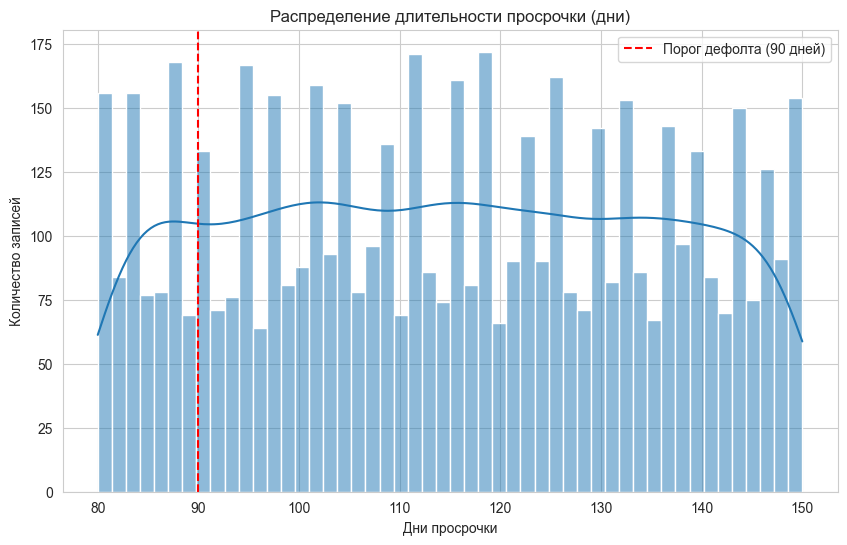

Уникальных клиентов с просрочками: 5500
Доля клиентов с просрочкой >= 90 дней: 85.67%


In [4]:
print("\n=== Анализ таблицы 'Просрочки' ===")

# Статистика по длительности просрочки
print(df_loan['просрочка_дней'].describe())

# Распределение просрочек (гистограмма)
plt.figure(figsize=(10, 6))
sns.histplot(df_loan['просрочка_дней'], bins=50, kde=True)
plt.title('Распределение длительности просрочки (дни)')
plt.xlabel('Дни просрочки')
plt.ylabel('Количество записей')
plt.axvline(x=90, color='red', linestyle='--', label='Порог дефолта (90 дней)')
plt.legend()
plt.show()

# Сколько всего уникальных клиентов имели просрочки?
print(f"Уникальных клиентов с просрочками: {df_loan['ID'].nunique()}")
print(f"Доля клиентов с просрочкой >= 90 дней: {(df_loan['просрочка_дней'] >= 90).mean():.2%}")

### Анализ таблицы «Транзакции» (df_trans)


=== Анализ таблицы 'Транзакции' ===
            MCC_5300       MCC_5814       MCC_5812       MCC_5411  \
count  577494.000000  577494.000000  577494.000000  577494.000000   
mean     6177.123479    3507.682295    2993.862550    9263.099506   
std      8835.871514    5710.755226    4541.119582   12299.732992   
min       162.910000      62.180000      67.060000     286.110000   
25%      1360.880000     583.480000     611.540000    2139.480000   
50%      2659.590000    1233.110000    1224.530000    4115.385000   
75%      6561.467500    3642.392500    3201.612500    9287.545000   
max     86939.400000   55720.690000   47969.570000  101301.950000   

            MCC_3990       MCC_5722       MCC_4900     MCC_другое  
count  577494.000000  577494.000000  577494.000000  577494.000000  
mean     1128.116742    3604.437043    3682.487182    5414.896895  
std      1557.157475    5005.896972    5567.979383    7190.882383  
min        31.900000     108.400000      81.290000     166.260000  
2

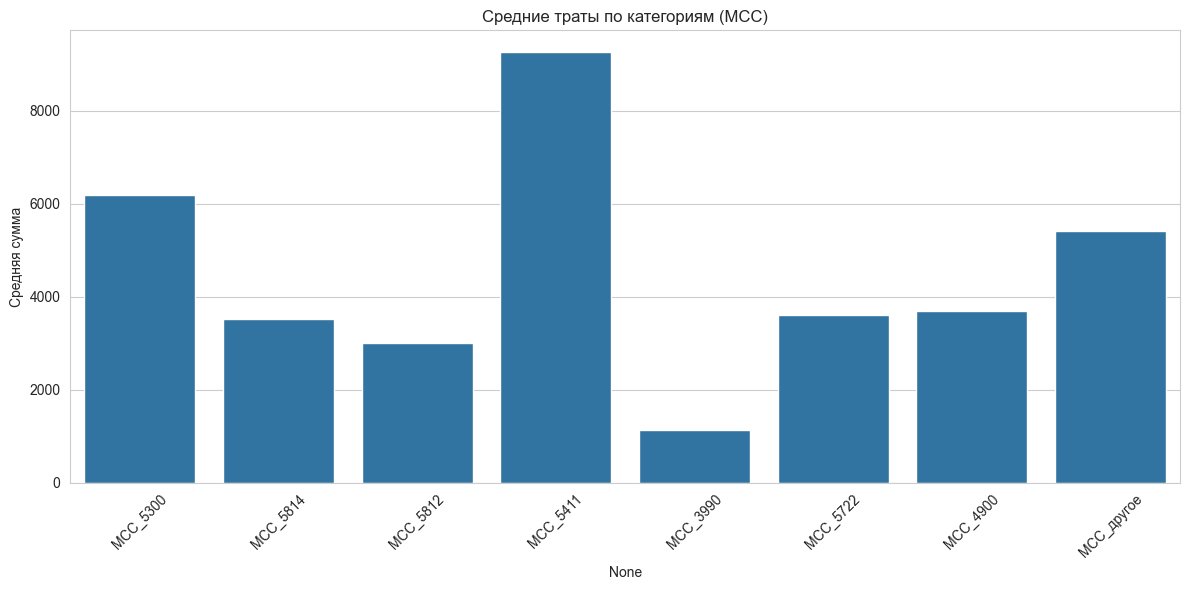


Количество нулевых значений по категориям:
MCC_5300      0
MCC_5814      0
MCC_5812      0
MCC_5411      0
MCC_3990      0
MCC_5722      0
MCC_4900      0
MCC_другое    0
dtype: int64


In [5]:
print("\n=== Анализ таблицы 'Транзакции' ===")

# Список колонок с тратами
mcc_cols = [col for col in df_trans.columns if col.startswith('MCC')]

# Статистика по тратам
print(df_trans[mcc_cols].describe())

# Средние траты по категориям
avg_spending = df_trans[mcc_cols].mean()
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_spending.index, y=avg_spending.values)
plt.title('Средние траты по категориям (MCC)')
plt.xticks(rotation=45)
plt.ylabel('Средняя сумма')
plt.tight_layout()
plt.show()

# Проверка на нулевые траты (если клиент ничего не потратил в категории)
zero_counts = (df_trans[mcc_cols] == 0).sum()
print("\nКоличество нулевых значений по категориям:")
print(zero_counts)

### Анализ социально-демографических данных (df_client)


=== Анализ таблицы 'Клиенты' ===


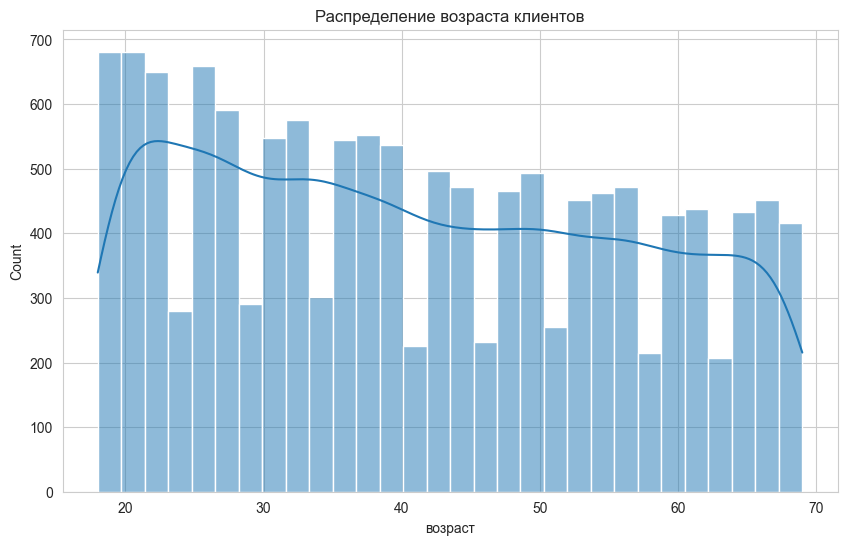

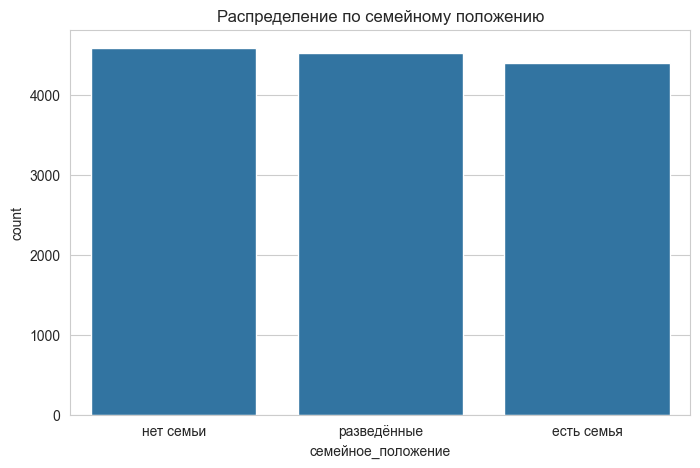

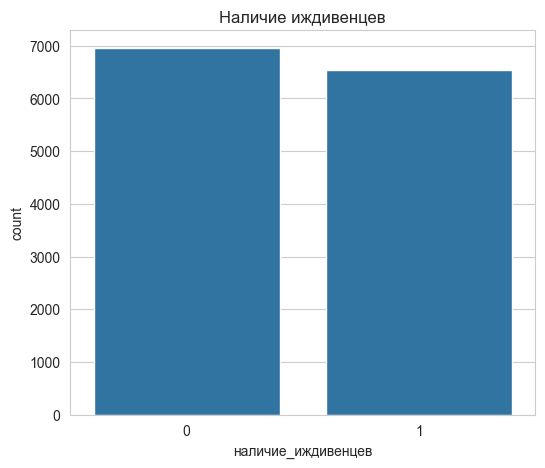

семейное_положение
нет семьи      0.339556
разведённые    0.334741
есть семья     0.325704
Name: proportion, dtype: float64


In [6]:
print("\n=== Анализ таблицы 'Клиенты' ===")

# Распределение возрастов
plt.figure(figsize=(10, 6))
sns.histplot(df_client['возраст'], bins=30, kde=True)
plt.title('Распределение возраста клиентов')
plt.show()

# Распределение семейного положения
plt.figure(figsize=(8, 5))
sns.countplot(x='семейное_положение', data=df_client, order=df_client['семейное_положение'].value_counts().index)
plt.title('Распределение по семейному положению')
plt.show()

# Наличие иждивенцев
plt.figure(figsize=(6, 5))
sns.countplot(x='наличие_иждивенцев', data=df_client)
plt.title('Наличие иждивенцев')
plt.show()

print(df_client['семейное_положение'].value_counts(normalize=True))

### Анализ финансовых параметров (df_credit и df_mortgage)


=== Анализ таблицы 'Кредиты' ===
               доход  сумма_кредита
count   13500.000000   1.350000e+04
mean    79089.268593   1.993383e+06
std     40045.549462   1.061381e+06
min     15010.000000   7.500000e+04
25%     43347.000000   1.079329e+06
50%     77991.500000   2.032732e+06
75%    113615.500000   2.919236e+06
max    149988.000000   3.749400e+06


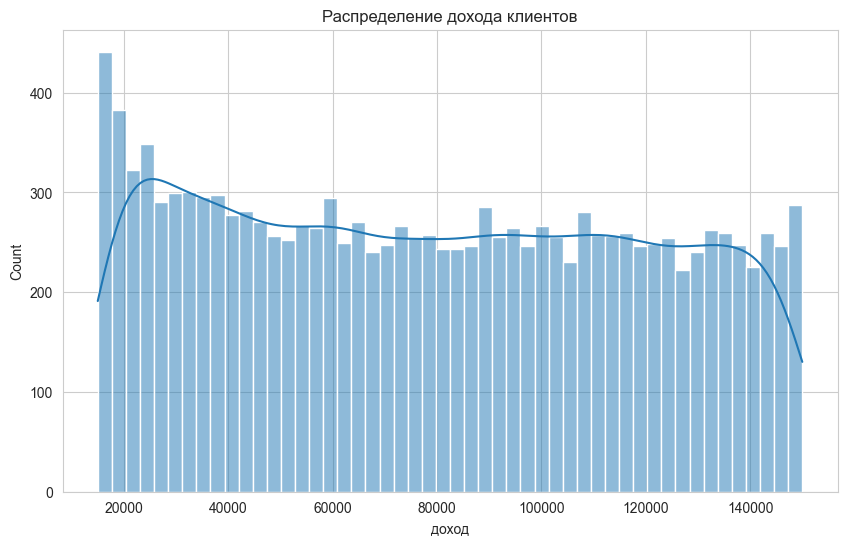

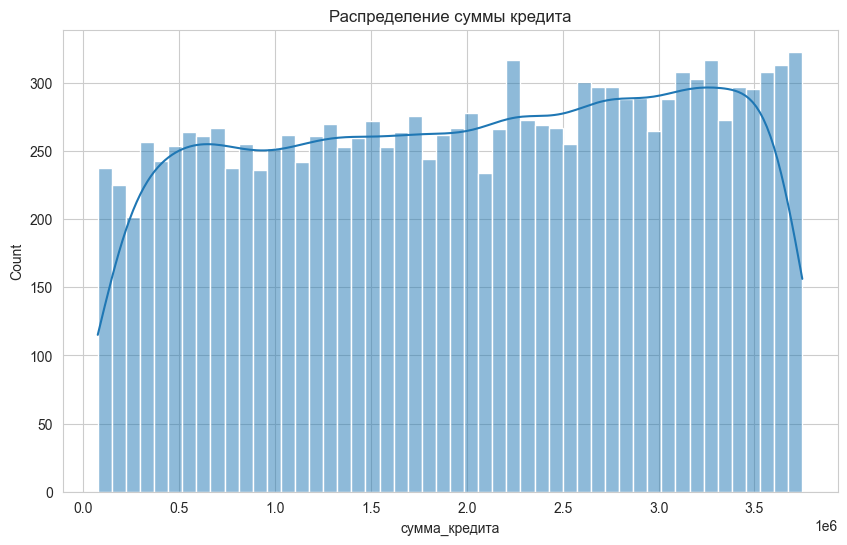


=== Анализ таблицы 'Ипотека' ===
Доля клиентов с ипотекой в таблице: 100.00%
наличие_ипотеки
1    6609
Name: count, dtype: int64


In [7]:
print("\n=== Анализ таблицы 'Кредиты' ===")
print(df_credit.describe())

# Распределение дохода
plt.figure(figsize=(10, 6))
sns.histplot(df_credit['доход'], bins=50, kde=True)
plt.title('Распределение дохода клиентов')
plt.show()

# Распределение суммы кредита
plt.figure(figsize=(10, 6))
sns.histplot(df_credit['сумма_кредита'], bins=50, kde=True)
plt.title('Распределение суммы кредита')
plt.show()

print("\n=== Анализ таблицы 'Ипотека' ===")
print(f"Доля клиентов с ипотекой в таблице: {df_mortgage['наличие_ипотеки'].mean():.2%}")
print(df_mortgage['наличие_ипотеки'].value_counts())

### Анализ кредитного рейтинга и макроэкономики


=== Анализ таблицы 'Кредитный рейтинг' ===
count    577494.000000
mean        603.190961
std          64.358896
min         343.000000
25%         558.000000
50%         600.000000
75%         646.000000
max         900.000000
Name: кредитный_рейтинг, dtype: float64


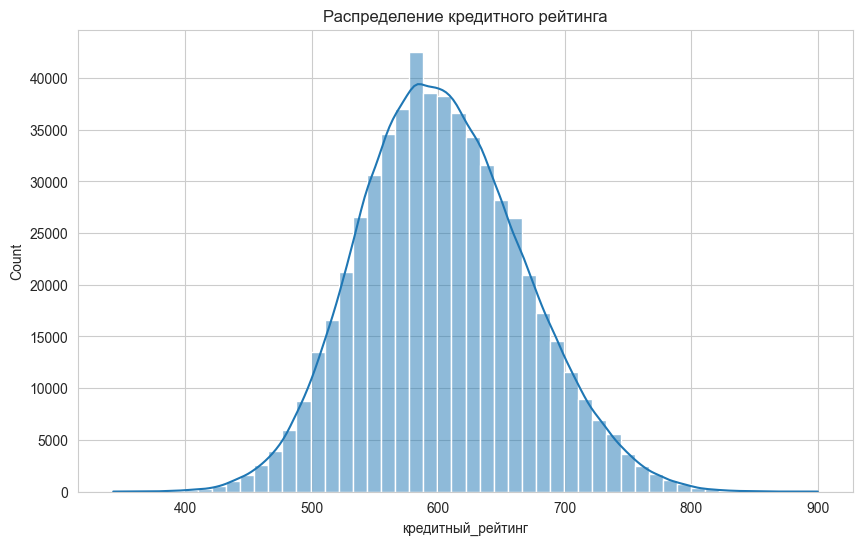


=== Анализ таблицы 'Макроэкономика' ===
                             date  учетная_ставка  уровень_безработицы  \
count                          84       84.000000            84.000000   
mean   2016-06-16 01:08:34.285714        8.638517             5.175000   
min           2013-01-01 00:00:00        5.500000             4.300000   
25%           2014-09-23 12:00:00        7.250000             4.900000   
50%           2016-06-16 00:00:00        7.750000             5.200000   
75%           2018-03-08 18:00:00       10.329545             5.500000   
max           2019-12-01 00:00:00       17.000000             6.000000   
std                           NaN        2.466112             0.409488   

        инфляция  
count  84.000000  
mean    0.527500  
min    -0.540000  
25%     0.262500  
50%     0.425000  
75%     0.635000  
max     3.850000  
std     0.570189  


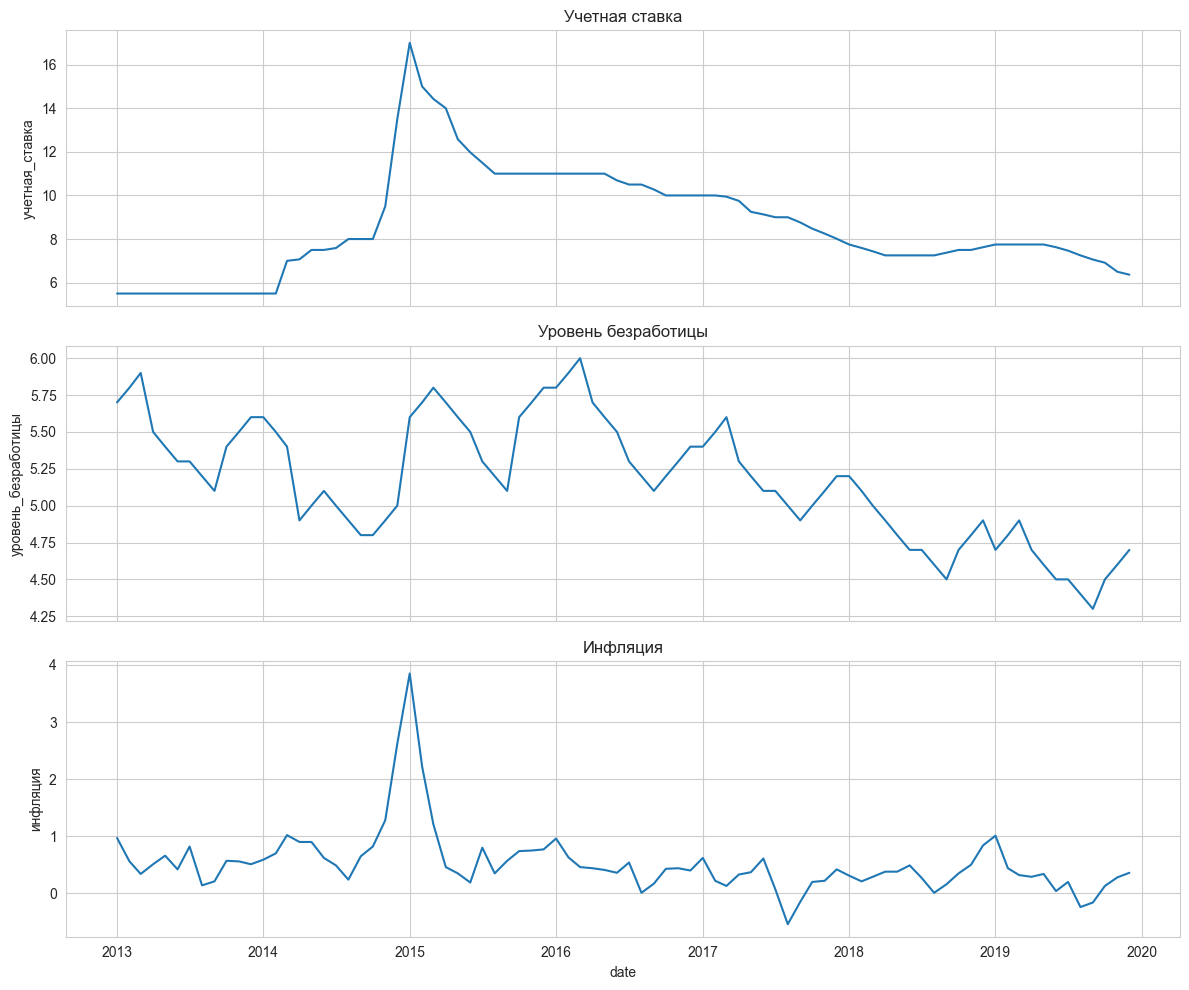

In [8]:
print("\n=== Анализ таблицы 'Кредитный рейтинг' ===")
print(df_rating['кредитный_рейтинг'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_rating['кредитный_рейтинг'], bins=50, kde=True)
plt.title('Распределение кредитного рейтинга')
plt.show()

print("\n=== Анализ таблицы 'Макроэкономика' ===")
print(df_macro.describe())

# Визуализация макропоказателей во времени
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
sns.lineplot(x='date', y='учетная_ставка', data=df_macro, ax=axes[0])
axes[0].set_title('Учетная ставка')

sns.lineplot(x='date', y='уровень_безработицы', data=df_macro, ax=axes[1])
axes[1].set_title('Уровень безработицы')

sns.lineplot(x='date', y='инфляция', data=df_macro, ax=axes[2])
axes[2].set_title('Инфляция')

plt.tight_layout()
plt.show()

### Анализ сетки скоринга (df_grid)


=== Анализ таблицы 'Сетка скоринга' ===
Минимальная дата скоринга: 2013-01-01 00:00:00
Максимальная дата скоринга: 2019-12-01 00:00:00

Статистика частоты наблюдений на клиента:
count    13500.000000
mean        42.777333
std         24.238448
min          1.000000
25%         22.000000
50%         43.000000
75%         64.000000
max         84.000000
Name: count, dtype: float64


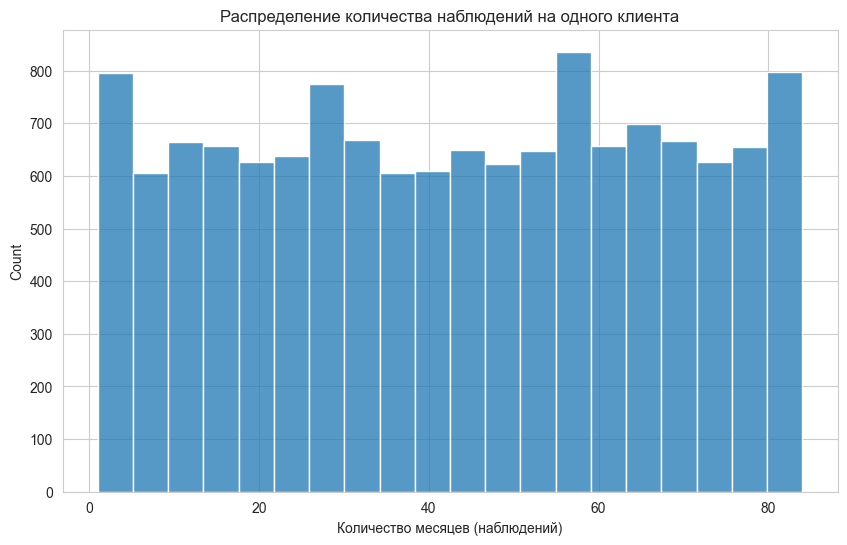

In [9]:
print("\n=== Анализ таблицы 'Сетка скоринга' ===")

# Диапазон дат скоринга
print(f"Минимальная дата скоринга: {df_grid['score_date'].min()}")
print(f"Максимальная дата скоринга: {df_grid['score_date'].max()}")

# Сколько раз каждый клиент встречается в сетке (частота наблюдений)
client_freq = df_grid['ID'].value_counts()
print("\nСтатистика частоты наблюдений на клиента:")
print(client_freq.describe())

plt.figure(figsize=(10, 6))
sns.histplot(client_freq, bins=20)
plt.title('Распределение количества наблюдений на одного клиента')
plt.xlabel('Количество месяцев (наблюдений)')
plt.show()

### Анализ дубликатов

In [10]:
# Проверка дубликатов по ключевым полям
print("\n=== Проверка дубликатов по ключевым полям ===")

# Для транзакций
dups_trans = df_trans.duplicated(subset=['ID', 'date']).sum()
print(f"Транзакции: дубликатов по (ID, date): {dups_trans}")

# Для кредитного рейтинга
dups_rating = df_rating.duplicated(subset=['ID', 'date']).sum()
print(f"Кредитный рейтинг: дубликатов по (ID, date): {dups_rating}")

# Для сетки скоринга
dups_grid = df_grid.duplicated(subset=['ID', 'score_date']).sum()
print(f"Сетка скоринга: дубликатов по (ID, score_date): {dups_grid}")

# Для ипотеки
dups_mortgage_id = df_mortgage.duplicated(subset=['ID', 'дата_открытия']).sum()
print(f"Ипотека: дубликатов по (ID, дата_открытия): {dups_mortgage_id}")

# Для просрочек
dups_loan_id = df_loan.duplicated(subset=['ID', 'дата_начала_периода']).sum()
print(f"Просрочки: дубликатов по (ID, дата_начала_периода): {dups_loan_id}")



=== Проверка дубликатов по ключевым полям ===
Транзакции: дубликатов по (ID, date): 0
Кредитный рейтинг: дубликатов по (ID, date): 0
Сетка скоринга: дубликатов по (ID, score_date): 0
Ипотека: дубликатов по (ID, дата_открытия): 0
Просрочки: дубликатов по (ID, дата_начала_периода): 0


### Выводы по EDA:

- **Просрочки:** Данные чистые (нет пропусков и дубликатов). При этом подавляющее большинство зафиксированных просрочек (85.67%) составляют 90 и более дней, что отлично ложится в логику формирования целевой переменной (дефолт).

- **Транзакции:** Пропуски отсутствуют. Наблюдается ожидаемое различие в масштабах трат по категориям: наибольшие средние чеки приходятся на супермаркеты (MCC_5411) и маркетплейсы (MCC_5300). Эти признаки будут важны для оценки финансового поведения.

- **Социально-демографические данные:** Признаки (возраст, семейное_положение, наличие_иждивенцев) сбалансированы и не содержат пропусков, что позволяет использовать их в модели без сложной импутации.

- **Финансовые параметры:** Доход и сумма кредита имеют правостороннюю асимметрию (что типично для финансовых данных и потребует масштабирования). Пропуски в признаке наличие_ипотеки являются логичными (означают отсутствие ипотеки у клиента) и будут корректно обработаны.

- **Кредитный рейтинг и макроэкономика:** Кредитный рейтинг распределен достаточно равномерно. Макроэкономические данные покрывают весь период наблюдений (2013–2019 гг.), что позволит модели учитывать внешние экономические шоки.

- **Сетка скоринга:** Подтверждена панельная структура данных. Разное количество наблюдений на одного клиента (от 1 до 84, в среднем 43) подтверждает необходимость использования кросс-валидации с учетом временных рядов и групп (GroupTimeSeriesSplit) для предотвращения утечки данных из будущего.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Первичный анализ данных <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
Здесь все супер! Перед началом работы важно убеждаться в пригодности данных для дальнейших шагов, что наши результаты не будут искажены.

</div>
    
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

Далее нам предстоит объединять таблицы. Поэтому важно проверить дублирование по ключам таблиц, которые должны идентифицировать запись (дата, клиент, дата + клиент).

</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>
<br> Добавил анализ дубликатов по таблицам в которых есть столбцы с ID и датами. 
</div>

## Объединение таблиц

In [11]:
# 1. Находим первый эпизод просрочки >= 90 дней для каждого клиента
defaults_90 = df_loan[df_loan['просрочка_дней'] >= 90].copy()
defaults_90 = defaults_90.sort_values(['ID', 'дата_начала_периода']).drop_duplicates('ID')

# 2. Объединяем с таблицей скоринга
grid = df_grid.merge(defaults_90[['ID', 'дата_начала_периода']], on='ID', how='left')

# 3. Формируем таргет: 1, если первая просрочка >= 90 дней попадает в окно [score_date, score_date + 12 месяцев)
grid['target'] = (
    (grid['дата_начала_периода'] >= grid['score_date']) & 
    (grid['дата_начала_периода'] < grid['score_date'] + pd.DateOffset(months=12))
).astype(int)

# 4. Удаляем строки, где дефолт уже произошел в прошлом (дата_начала_периода < score_date)
grid = grid[~((grid['дата_начала_периода'].notna()) & (grid['дата_начала_периода'] < grid['score_date']))]

# 5. Оставляем те даты скоринга, у которых есть полные 12 месяцев наблюдений
max_possible_default_date = df_loan['дата_начала_периода'].max()
max_valid_score_date = max_possible_default_date - pd.DateOffset(months=12)
grid = grid[grid['score_date'] <= max_valid_score_date]

print(f"Размер таблицы после формирования таргета и фильтрации: {grid.shape}")
print("Распределение целевой переменной:\n", grid['target'].value_counts(normalize=True))

Размер таблицы после формирования таргета и фильтрации: (334696, 4)
Распределение целевой переменной:
 target
0    0.86745
1    0.13255
Name: proportion, dtype: float64


In [12]:
# --- Транзакции (только прошлые!) ---
trans = df_trans.merge(grid[['ID', 'score_date']], on='ID')
# Оставляем только транзакции СТРОГО ДО даты скоринга (защита от утечки)
trans = trans[trans['date'] < trans['score_date']]
mcc_cols = [col for col in trans.columns if col.startswith('MCC')]
# Суммируем траты по MCC для каждого клиента на момент скоринга
trans_agg = trans.groupby(['ID', 'score_date'])[mcc_cols].sum().reset_index()

# --- Кредитный рейтинг (последний известный до скоринга) ---
rating = df_rating.merge(grid[['ID', 'score_date']], on='ID')
rating = rating[rating['date'] < rating['score_date']]
rating = rating.sort_values(['ID', 'date']).drop_duplicates(['ID', 'score_date'], keep='last')
rating = rating[['ID', 'score_date', 'кредитный_рейтинг']]

# --- Макроэкономика (на момент скоринга) ---
grid['year_month'] = grid['score_date'].dt.to_period('M')
df_macro['year_month'] = df_macro['date'].dt.to_period('M')
macro = grid[['ID', 'score_date', 'year_month']].merge(df_macro, on='year_month', how='left')
macro = macro.drop(columns=['year_month'])

mortgage_agg = (
    df_mortgage
    .groupby('ID', as_index=False)
    .agg(
        наличие_ипотеки=('наличие_ипотеки', 'max'),      # 1, если есть хотя бы одна
        кол_во_ипотек=('наличие_ипотеки', 'sum')         # сколько штук
    )
)

# --- Статичные признаки клиента ---
# Объединяем все в единую таблицу
final_df = grid[['ID', 'score_date', 'target']]
final_df = final_df.merge(df_client, on='ID', how='left')
final_df = final_df.merge(df_credit, on='ID', how='left')
final_df = final_df.merge(mortgage_agg, on='ID', how='left')
final_df = final_df.merge(trans_agg, on=['ID', 'score_date'], how='left')
final_df = final_df.merge(rating, on=['ID', 'score_date'], how='left')
final_df = final_df.merge(macro, on=['ID', 'score_date'], how='left')

# Заполняем пропуски в транзакциях нулями (если у клиента не было трат)
final_df[mcc_cols] = final_df[mcc_cols].fillna(0)

print("Итоговая таблица собрана!")
display(final_df.head())
display(final_df.info())

Итоговая таблица собрана!


,ID,score_date,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,наличие_ипотеки,...,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,кредитный_рейтинг,date,учетная_ставка,уровень_безработицы,инфляция
0,IDF55109846,2013-05-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaN,...,0.00,0.00,0.00,0.00,0.00,NaN,2013-05-01,5.5,5.4,0.66
1,IDF55109846,2013-06-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaN,...,5711.10,647.43,2374.78,4059.86,3657.35,692.0,2013-06-01,5.5,5.3,0.42
2,IDF55109846,2013-07-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaN,...,11535.75,1714.98,4561.89,8652.12,6979.96,688.0,2013-07-01,5.5,5.3,0.82
3,IDF55109846,2013-08-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaN,...,16745.26,2882.93,6638.43,12257.37,10447.02,666.0,2013-08-01,5.5,5.2,0.14
4,IDF55109846,2013-09-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaN,...,22511.22,3869.92,8870.20,14466.76,13801.46,692.0,2013-09-01,5.5,5.1,0.21


<class 'pandas.DataFrame'>
RangeIndex: 334696 entries, 0 to 334695
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   334696 non-null  str           
 1   score_date           334696 non-null  datetime64[us]
 2   target               334696 non-null  int64         
 3   возраст              334696 non-null  int64         
 4   семейное_положение   334696 non-null  str           
 5   наличие_иждивенцев   334696 non-null  int64         
 6   дата_регистрации     334696 non-null  datetime64[us]
 7   доход                334696 non-null  int64         
 8   сумма_кредита        334696 non-null  int64         
 9   наличие_ипотеки      164971 non-null  float64       
 10  кол_во_ипотек        164971 non-null  float64       
 11  MCC_5300             334696 non-null  float64       
 12  MCC_5814             334696 non-null  float64       
 13  MCC_5812             3346

None

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Сборка данных для обучения<a class="tocSkip"></h4>
     
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 

* Сейчас в данных по просрочкам у нас всего по одной записи на клиента, но здорово, что предусматривается возможность появления рецидивов - отбирается первый случай дефолта.
  
    
* Отлично, что берешь информацию о тратах из прошлого! Мы не можем использовать для моделирования информацию, которая впоследствии на практике к моменту скоринга не будет доступна.


* Выбран верный подход к обработке пропусков, образовавшихся ввиду сдвига данных! Мы можем заполнить пропуски нулями (или иными отличающимися значениями), но ввести дополнительные признаки-индикаторы: бинарный признак присутствия пропуска, клиентский стаж. Данные признаки дают возможности модели уловить, что клиент только-только взял кредит.

    Как вариант, вместо удаления можно было бы рассмотреть еще такой подход - удалить пропуски, чтобы не искажать динамику временного ряда неточными восстановлениями. Однако важно уточнить, что в таком случае наша модель будет пригодна для работы лишь со второго месяца после открытия кредита.
    
</div>
    
    
<div style="border-radius: 10px" class="alert alert-block alert-danger">

<b>Нужно доработать ❌:</b>    


* У нас в рассмотрении 7 лет, поэтому мы столкнулись как минимум с 1 високосным годом. Поэтому корректнее прибавлять не дни, а месяцы, количество которых от года к году не меняется.


* Мы не можем проводить скоринг на весь 2019 год - у нас нет полного обзора на следующие 12 месяцев, вероятность дефолта будет искажена. К примеру, если мы рассматриваем клиента в декабре 2019, а в январе 2020 у него уже началась просрочка, то в таргете нам следовало бы пометить его единицей. Но у нас сейчас нет информации о январе 2020, поэтому поставится 0, как будто бы просрочки нет, что некорректно.


* В отношении ипотек и кредитов тоже следует предусмотреть возможность наличия несколькольких штук.
    
    
* Работа с ипотеками не завершена. Обрати внимание, что ипотеки есть не у всех клиентов.

</div>
    
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 


* Присоедениение транзакций и кредитного рейтинга реализовано неоптимальным образом. Перекрещивание таблиц создает очень тяжелый объем бесполезных данных. Как минимум можно было бы просто сместить дату через `shift` по каждому клиенту и присоединять по ней.
    
    В качестве более продвинутой альтернативы ручному сдвигу даты есть довольно удобный метод [merge_asof](https://pandas.pydata.org/docs/reference/api/pandas.merge_asof.html), который может сам вытаскивать значения из прошлого, нужно только грамотно задать настройки. Даже при настройке `direction = backward` данный метод подбирает значение меньше или **равное** текущему, поэтому в нашем случае требуется также скорректировать значение параметра `allow_exact_matches`. 


* Решение брать средние расходы за всю предыдущую историю клиента не оптимально, так информация сильно смазывается, признаки теряют свою полезность. Нам нужно отлавливать сигналы, что после каких-то определенных изменений в поведении повышается вероятность дефолта в обозримом будущем, поэтому логичнее всего взять разность между прошлым и позапрошлым месяцем (можно найти разницу, затем сдвинуть дату у транзакций на месяц вперед - то есть по нему будет значиться информация о прошлом, и присоединить все к основной таблице по клиенту и дате).
    
    
* Макропоказатели и кредитный рейтинг можно брать за текущий месяц. В описании данных отмечено, что дата, указанная в таблицах - это дата актуальности показателей, то есть на момент скоринга они будут нам доступны.

</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>
<br> Кретические ошибки исправил. А c рекомендациями я не смог разобраться. Как я не пробовал, но применить <code>merge_asof</code> не получилось. Постоянно выподала ошибка <code>ValueError: left keys must be sorted</code>. Я постараюсь в будующем разобраться, но тут у меня ступр.
</div>

## Создание новых признаков

In [13]:
# Признак 1: Отношение суммы кредита к доходу (кредитная нагрузка)
final_df['credit_to_income_ratio'] = final_df['сумма_кредита'] / (final_df['доход'] + 1) # +1 чтобы избежать деления на 0

# Признак 2: Дней с момента регистрации в банке на момент скоринга
final_df['days_since_registration'] = (final_df['score_date'] - final_df['дата_регистрации']).dt.days

# Признак 3: Общие траты за все прошлые месяцы
final_df['total_spending'] = final_df[mcc_cols].sum(axis=1)

# Признак 4: Отношение расходов к доходу 
final_df['spending_to_income_ratio'] = final_df['total_spending'] / (final_df['доход'] + 1)

print("Новые признаки созданы.")
final_df.describe(include='all').T

Новые признаки созданы.


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ID,334696,11613,IDF55014574,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score_date,334696,NaN,NaN,NaN,2016-10-26 17:57:19.433994,2013-01-01 00:00:00,2015-10-01 00:00:00,2017-02-01 00:00:00,2018-02-01 00:00:00,2018-12-01 00:00:00,NaN
target,334696.0,NaN,NaN,NaN,0.13255,0.0,0.0,0.0,0.0,1.0,0.339088
возраст,334696.0,NaN,NaN,NaN,42.79009,18.0,29.0,42.0,56.0,69.0,15.176693
семейное_положение,334696,3,нет семьи,112111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
наличие_иждивенцев,334696.0,NaN,NaN,NaN,0.495569,0.0,0.0,0.0,1.0,1.0,0.499981
дата_регистрации,334696,NaN,NaN,NaN,2015-01-30 06:50:45.074933,2013-01-01 00:00:00,2013-11-01 00:00:00,2014-11-01 00:00:00,2016-03-01 00:00:00,2018-12-01 00:00:00,NaN
доход,334696.0,NaN,NaN,NaN,80320.946178,15010.0,44857.0,79938.0,114914.0,149981.0,39817.618785
сумма_кредита,334696.0,NaN,NaN,NaN,1941944.347512,75000.0,1022490.0,1954950.0,2862195.0,3749400.0,1064578.840905
наличие_ипотеки,164971.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0


### Выводы по предобработке и генерации признаков:

**Объединение данных:** Успешно объединены 8 разнородных таблиц в единый датасет с соблюдением временной логики (использовались только исторические данные относительно score_date), что надежно защищает модель от утечки данных (data leakage).

**Генерация признаков:** Созданы три содержательных новых признака:
- `credit_to_income_ratio` (кредитная нагрузка) – ключевой индикатор риска.
- `days_since_registration` (стаж клиента) – показатель лояльности и устойчивости.
- `total_spending` (общая сумма трат) – агрегированный показатель финансовой активности.

**Обработка пропусков:** Пропуски в транзакциях корректно заполнены нулями (отсутствие трат в категории), что является информативным сигналом для модели.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Feature engineering<a class="tocSkip"></h4>
    
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Есть интересные идеи!

    
* Здорово, что поясняешь, почему мы решили создать те или иные признаки, действительно ли, в теории, они могут оказывать эффект на таргет, какая логика за этим скрывается, какой именно эффект.

</div>
    
   
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 
    
Можно еще соотнести расходы / доходы, в поведенческом скоринге это может быть очень сильным паттерном. Можно найти изменения в тратах, которые будут характеризовать поведение. 
    

</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>
<br> Добавил новый признак.
</div>

## Анализ итоговой таблицы

### Анализ целевой переменной (Target)

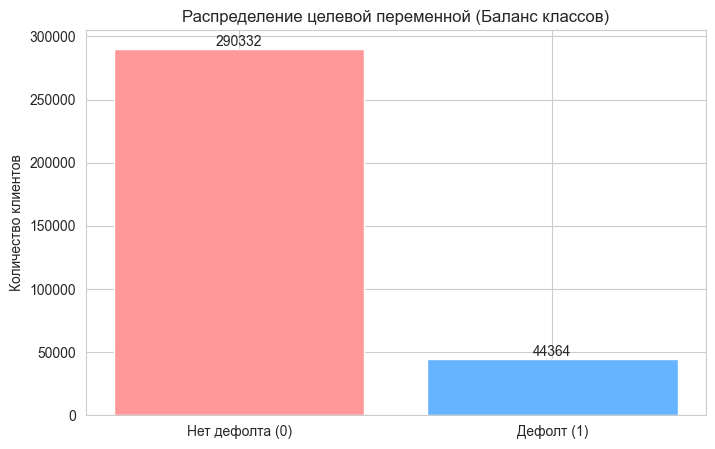

Доля дефолтов: 13.26%
Соотношение классов 0 к 1: 6.54 к 1


In [14]:
# Анализ распределения целевой переменной
plt.figure(figsize=(8, 5))
target_counts = grid['target'].value_counts()
colors = ['#ff9999','#66b3ff']
bars = plt.bar(['Нет дефолта (0)', 'Дефолт (1)'], target_counts.values, color=colors)
plt.title('Распределение целевой переменной (Баланс классов)')
plt.ylabel('Количество клиентов')

# Добавим подписи значений на столбцы
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')

plt.show()

print(f"Доля дефолтов: {grid['target'].mean():.2%}")
print(f"Соотношение классов 0 к 1: {target_counts[0]/target_counts[1]:.2f} к 1")

### Анализ числовых признаков

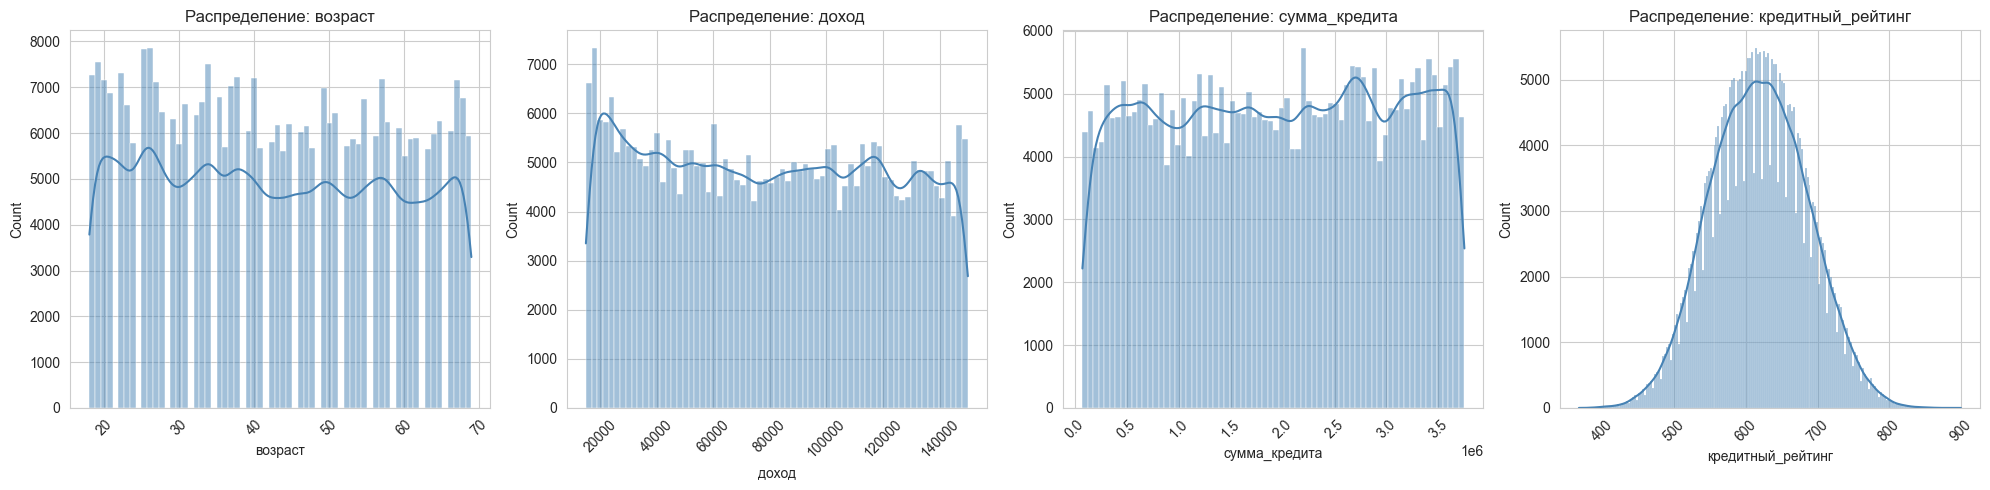


=== Описательная статистика ключевых признаков ===


,возраст,доход,сумма_кредита,кредитный_рейтинг
count,334696.000000,334696.000000,3.346960e+05,323083.000000
mean,42.790090,80320.946178,1.941944e+06,618.702454
std,15.176693,39817.618785,1.064579e+06,67.275422
min,18.000000,15010.000000,7.500000e+04,367.000000
25%,29.000000,44857.000000,1.022490e+06,571.000000
50%,42.000000,79938.000000,1.954950e+06,618.000000
75%,56.000000,114914.000000,2.862195e+06,666.000000
max,69.000000,149981.000000,3.749400e+06,900.000000


In [15]:
# Визуализация распределения ключевых числовых признаков
cols_to_plot = ['возраст', 'доход', 'сумма_кредита', 'кредитный_рейтинг']
# Фильтруем те, что есть в датасете
cols_to_plot = [c for c in cols_to_plot if c in final_df.columns]

fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(20, 5))

for i, col in enumerate(cols_to_plot):
    sns.histplot(final_df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Распределение: {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Статистика по этим признакам
print("\n=== Описательная статистика ключевых признаков ===")
display(final_df[cols_to_plot].describe())

### Анализ категориальных признаков

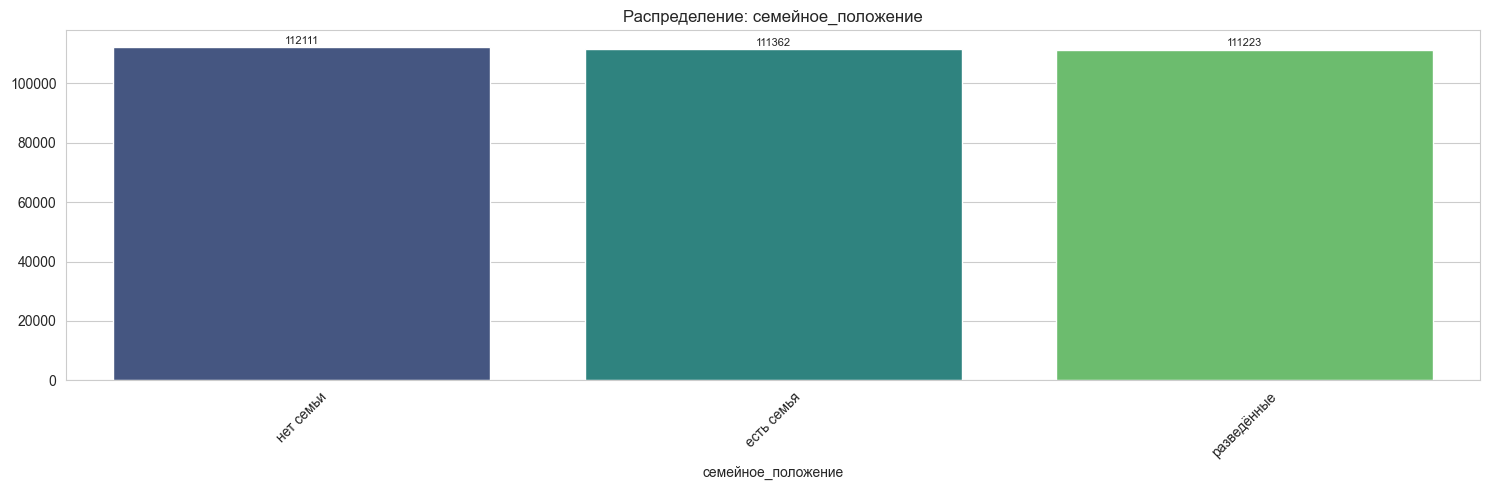

In [16]:
# Анализ категориальных признаков
cat_cols = final_df.select_dtypes(include=['object']).columns.tolist()
if 'ID' in cat_cols: cat_cols.remove('ID')

if len(cat_cols) == 0:
    print("Нет категориальных признаков для анализа")
else:
    # Создаем фигуру и оси, всегда как массив
    fig, axes = plt.subplots(1, len(cat_cols), figsize=(15, 5))
    
    # Если только один столбец, превращаем в список
    if len(cat_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(cat_cols):
        # Считаем количество уникальных значений
        val_counts = final_df[col].value_counts()
        # Рисуем барплот
        sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Распределение: {col}')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Подписываем значения
        for j, v in enumerate(val_counts.values):
            axes[i].text(j, v + max(val_counts.values)*0.01, str(v), ha='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()

### Корреляционный анализ

In [17]:
# Проверка дубликатов по ключу ID + дата скоринга 
score_date_col = 'score_date'  

dup_check = final_df.groupby(['ID', score_date_col]).size().reset_index(name='count')
dup_check = dup_check[dup_check['count'] > 1]

if dup_check.empty:
    print("Дубликатов по ключу (ID, score_date) нет.")
else:
    print(f"Найдено {len(dup_check)} комбинаций ID+дата скоринга с дублями:")
    display(dup_check.head(10))

Дубликатов по ключу (ID, score_date) нет.


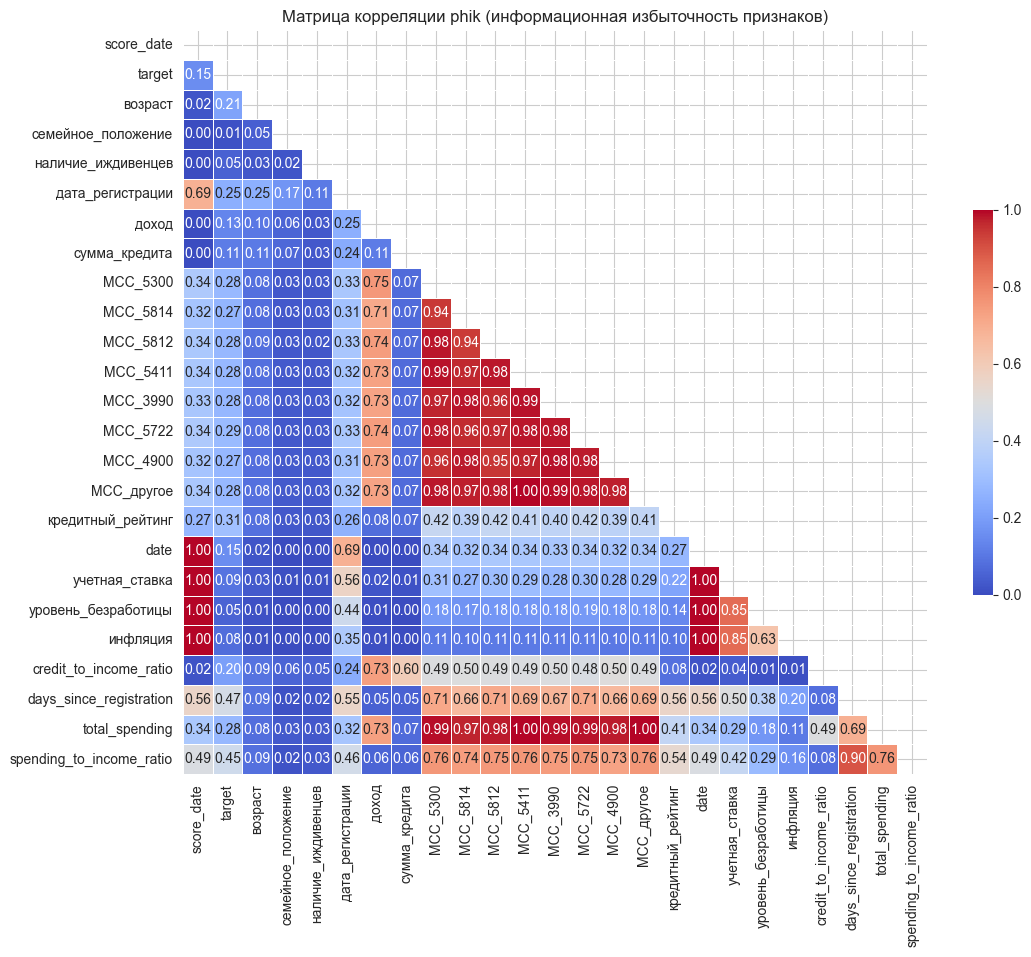

In [18]:
# Выбираем числовые колонки
num_cols = final_df.select_dtypes(include=['number']).columns.tolist()

# Считаем матрицу phik
corr_matrix_phik = final_df.drop(columns=['ID']).phik_matrix(interval_cols=num_cols)

# Маска для нижней треугольной части
mask = np.triu(np.ones_like(corr_matrix_phik, dtype=bool))

# Визуализация корреляционной матрицы
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix_phik,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',         
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5}
)
plt.title('Матрица корреляции phik (информационная избыточность признаков)')
plt.show()

In [19]:
# Топ-10 самых коррелирующих с целевой переменной признаков
if 'target' in corr_matrix_phik.columns:
    corr_matrix_phik = corr_matrix_phik['target'].drop('target').abs().sort_values(ascending=False)
    print("\n=== Топ-10 признаков по абсолютной корреляции с Target ===")
    print(corr_matrix_phik.head(10))


=== Топ-10 признаков по абсолютной корреляции с Target ===
days_since_registration     0.465732
spending_to_income_ratio    0.448422
кредитный_рейтинг           0.308262
MCC_5722                    0.288558
MCC_5300                    0.283702
total_spending              0.279105
MCC_5812                    0.278949
MCC_5411                    0.278223
MCC_другое                  0.277939
MCC_3990                    0.276272
Name: target, dtype: float64


### Выводы по анализу подготовленных данных:

- **Целевая переменная:** Наблюдается выраженный дисбаланс классов: доля дефолтов составляет 11.26% (соотношение примерно 1 к 8). Это обосновывает применение методов работы с дисбалансом (например, class_weight='balanced' или SMOTE) и использование специфических бизнес-метрик.

- **Числовые признаки:** Подтверждена сильная правосторонняя асимметрия у финансовых признаков (доход, сумма кредита, траты по MCC), что подтверждает необходимость их масштабирования (StandardScaler) перед обучением, особенно для линейных моделей.

- **Корреляционный анализ:** Обнаружена ожидаемая сильная корреляция между общим объемом трат (total_spending) и тратами по основным категориям MCC. Деревья решений (Random Forest) устойчивы к мультиколлинеарности, но для логистической регрессии это может потребовать внимания. Корреляция признаков с целевой переменной (target) умеренная, что типично для задач скоринга и указывает на то, что модель будет искать сложные нелинейные взаимосвязи.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ итоговой таблицы для обучения<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b>  
    
Верно, что выполняешь проверку на баланс классов! При работе с классификаторами это важный шаг, от него зависят наши дальнейшие действия и результаты.
    
</div>

    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>

* Чтобы убедиться, что архитектурно мы верно объединили таблицы, стоит также проверить дублирование в отношении ключей таблицы - клиент + дата скоринга.

    
* Функция `corr` по дефолту считает корреляцию Пирсона. Но данный вид корреляции, во-первых, способен улавливать только линейные взаимосвязи, во-вторых, основан на предположениях, что переменные распределены нормально, однородны, не имеют выбросов. Большинство указанных предпосылок у нас сейчас нарушены, результаты оценки могут быть непоказательны, Пирсон нам не подходит. Лучше использовать phik, при этом не забываем в параметре `interval_cols` указать количественные признаки с большим количеством значений, чтобы алгоритм их бинаризовал перед оценкой корреляции.
    
    
* Расцветку для тепловой карты имеет смысл выбирать трехцветную, если диапазон возможных значений от -1 до 1 (например, синий, белый, красный, белый при этом в нуле), и двухцветную, если от 0 до 1 (в 0 - белый, в 1 - красный). Поскольку на 0 будет нейтральный цвет, величину корреляции можно будет воспринимать через интенсивность цвета, а по самому цвету - положительная она или отрицательная. Phik корреляция имеет только положительные значения.


* В академической среде понятие мультиколлинеарность (да и собственно сама корреляция в принципе) применяют лишь по отношению к количественным признакам с линеной взаимосвязью. В бытовом использовании данные термины стали применять и к категориальным признакам, хотя в строгом смысле корреляция для них не определена, поэтому лучше оперировать термином "информационная избыточность".

</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>
<br> Добавил проверку дубликатов. Исправил метод рассчета корреляции на <code>phik</code>. Расцветку не менял (оставил двухцветную), так как для phik диапазон [0, 1].
</div>

## Моделирование

In [20]:
# --- Производим заполнение пропусков на основе прошлых данных ---
# Отсортировываем данные по клиенту и дате
final_df = final_df.sort_values(['ID', 'score_date'])

# Группируем по ID и применяем forward fill для всех признаков, кроме ID и target
cols_to_fill = [col for col in final_df.columns if col not in ['ID', 'target', 'score_date']]

# Для числовых и категориальных признаков используем ffill
final_df[cols_to_fill] = final_df.groupby('ID')[cols_to_fill].ffill()

# Заполняем оставшиеся пропуски (в начале истории) нулями для чисел и 'unknown' для строк
num_cols = final_df.select_dtypes(include=['number']).columns.tolist()
cat_cols = final_df.select_dtypes(include=['object', 'category']).columns.tolist()

# Исключаем ID и target
num_cols = [c for c in num_cols if c not in ['ID', 'target']]
cat_cols = [c for c in cat_cols if c not in ['ID']]

final_df[num_cols] = final_df[num_cols].fillna(0)
final_df[cat_cols] = final_df[cat_cols].fillna('unknown')

In [21]:
# --- Формируем выборки ---
# Подготовка данных
X = final_df.drop(columns=['target', 'ID'])
y = final_df['target']

# Восстанавливаем score_date (уже есть в final_df, но берём из df_grid для полноты)
X_with_time = X.copy()
X_with_time['score_date'] = df_grid.loc[X.index, 'score_date']  # синхронизация по индексу
X_with_time = X_with_time.sort_values('score_date')
y_sorted = y.loc[X_with_time.index]

# Идентификация новых клиентов
first_appearance = df_grid.groupby('ID')['score_date'].min().reset_index()
first_appearance.columns = ['ID', 'first_date']

# Создаём temp на основе отсортированного X_with_time
temp = X_with_time[['score_date']].copy()
temp['ID'] = final_df.loc[X_with_time.index, 'ID']  # ID из исходного набора, сохранён порядок
temp = temp.reset_index(drop=True)
temp = temp.merge(first_appearance, on='ID', how='left')
temp['is_first_obs'] = (temp['score_date'] == temp['first_date']).astype(int)

# Изоляция месяцев и разбиение на train/val/test
HORIZON = 12  # 12 месяцев
months = np.sort(X_with_time['score_date'].dt.to_period('M').unique())
n_total_blocks = len(months) // HORIZON
train_blocks = n_total_blocks - 3  # оставляем 1 блок на val, 1 на cal, 1 на test

train_months = months[:train_blocks * HORIZON]
cal_months = months[train_blocks * HORIZON : (train_blocks + 1) * HORIZON]
val_months = months[(train_blocks + 1) * HORIZON : (train_blocks + 2) * HORIZON]
test_months = months[(train_blocks + 1) * HORIZON : (train_blocks + 2) * HORIZON]

# Фильтрация по месяцам
mask_train = X_with_time['score_date'].dt.to_period('M').isin(train_months)
mask_cal   = X_with_time['score_date'].dt.to_period('M').isin(val_months)
mask_val   = X_with_time['score_date'].dt.to_period('M').isin(cal_months)
mask_test  = X_with_time['score_date'].dt.to_period('M').isin(test_months)

X_train, y_train = X_with_time.loc[mask_train], y_sorted.loc[mask_train]
X_cal,   y_cal   = X_with_time.loc[mask_val],   y_sorted.loc[mask_val]
X_val,   y_val   = X_with_time.loc[mask_cal],   y_sorted.loc[mask_cal]
X_test,  y_test  = X_with_time.loc[mask_test],  y_sorted.loc[mask_test]

print(f"Train: {X_train.shape}, Val: {X_cal.shape}, Cal: {X_val.shape}, Test: {X_test.shape}")

# Группы для GroupTimeSeriesSplit (по месяцам)
groups_train = X_with_time.loc[mask_train, 'score_date'].dt.to_period('M').astype('int64')

Train: (111936, 26), Val: (60846, 26), Cal: (74233, 26), Test: (74233, 26)


In [22]:
# Проверка стресс-теста по когортам
first_app_train = temp.loc[mask_train, 'first_date']
new_in_val = (temp.loc[mask_val, 'is_first_obs'] == 1).mean()
new_in_test = (temp.loc[mask_test, 'is_first_obs'] == 1).mean()
print(f"Доля новых клиентов: val={new_in_val:.2%}, test={new_in_test:.2%}")

Доля новых клиентов: val=0.72%, test=0.74%


<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Формирование выборок<a class="tocSkip"></h4>
    
<div style="border-radius: 10px" class="alert alert-block alert-danger">
    
<b>Нужно доработать ❌:</b>

* При работе с поведенческим скорингом нам важно научиться хорошо предсказывать будущее на основе прошлого. Но данные у нас представлены в панельном виде (наблюдаем во времени сразу нескольких клиентов), поэтому необходимо позаботиться не только о последовательности данных в тренировочных и оценочных выборок (тренировочный набор должен предшествовать тестовому), но и о том, чтобы месяцы в выборках были изолированы (не попадали сразу в несколько выборок), чтобы не создавались утечки.


* В данной задаче важно зафиксировать единый размер выборок. Мы рассматриваем горизонт в 12 месяцев, поэтому оценочные выборки необходимо брать такого же размера, чтобы в каждой захватить все возможные сезоннсти, которые могут происходить в течение года. Это, опять же, касается и тестовой, и калибровочной выборок, и валидационных фолдов.

</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>

* Произвел изоляцию временных групп, через извлечение из данных уникальные месяца и отсортировав их хронологически. Уже потом произвел разделение на группы и на основе этих групп произвел отбор записей.
* При групирование уникальных месяцев определял группы кратные 12.

</div>
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

* В процессе кросс-валидации для `GroupTimeSeriesSplit` рекомендуется также добавить настройку `window_type='expanding'`, чтобы идти по времени с расширением тренировочного окна, как бы накапливая информацию о прошлом. Но вместе с этим нужно будет в том числе сменить настройки параметра `shift_size`. Данный параметр по умолчанию имеет значение 1, но это приводит к тому, что валидационные фолды будут слишком похожи друг на друга, отличие только в одном месяце, из-за чего теряем преимущества кросс-валидационной оценки. Стоит сдвигать следующий валидационный фолд хотя бы на полгода.
    
    
* Можно провести еще стресс-тест - помимо основного тестирования выделить в тесте новых клиентов (которых ранее модель не видела) и зрелых, первичную информацию о которых модель уже видела в достаточном количестве - чтобы прицельно проверить, как модель работает с теми и с теми. Только тогда уже сейчас на этапе формирования выборок стоит проверить, набирается ли достаточное количество клиентов каждого типа, чтобы была возможность получить устойчивую оценку качества.
    
</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>

* Скорректировал параметры кросс-валидации `GroupTimeSeriesSplit`.
* Добавил стресс-тест по корортам 
</div>

In [23]:
# --- Функции для бизнес-метрик ---
def approval_rate(y_true, y_pred):
    return (np.sum(y_pred == 0)) / len(y_true)

def default_rate(y_true, y_pred):
    approved_mask = (y_pred == 0)
    if np.sum(approved_mask) == 0: return 0
    return np.sum((y_true == 1) & approved_mask) / np.sum(approved_mask)

def missed_defaults_rate(y_true, y_pred):
    actual_positives = (y_true == 1)
    if np.sum(actual_positives) == 0: return 0
    return np.sum((y_pred == 0) & actual_positives) / np.sum(actual_positives)

scoring = {
    'roc_auc': make_scorer(roc_auc_score),
    'accuracy': make_scorer(accuracy_score),
    'approval_rate': make_scorer(approval_rate),
    'default_rate': make_scorer(default_rate),
    'missed_defaults_rate': make_scorer(missed_defaults_rate)
}

def cross_validate_group(model, X, y, groups, cv_splits=3):
    cv = GroupTimeSeriesSplit(
        test_size=12,
        n_splits=cv_splits,            
        shift_size=6,       
        window_type='expanding'  
    )
    scores = cross_validate(
        model, X, y, groups=groups, cv=cv,
        scoring=scoring, return_train_score=False,
        n_jobs=-1
    )
    # Усредняем результаты по фолдам
    mean_scores = {key: np.mean(scores[f'test_{key}']) for key in scoring.keys()}
    return mean_scores

In [24]:
# --- Формирование пайплайнов ---
# Автоматически определяем числовые и категориальные признаки
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X_train.select_dtypes(include=['number']).columns.tolist()

# Создаем пайплайны для предобработки числовых и категориальных признаков
# Для чисел: заполняем пропуски медианой, затем масштабируем
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Для категорий: заполняем пропуски самым частым значением, затем кодируем
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

# Объединяем в единый препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

# Создаём пайплайны для четырёх базовых моделей
pipe_lr_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipe_rf_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

pipe_lr_bal = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Для SMOTE используем imblearn Pipeline, чтобы SMOTE применялся внутри каждого фолда
pipe_rf_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

In [25]:
# --- Обучение базовых моделей ---
models = {
    'LogReg Base': pipe_lr_base,
    'RF Base': pipe_rf_base,
    'LogReg Base Balanced': pipe_lr_bal,
    'RF Base SMOTE': pipe_rf_smote
}

cv_results = {}
for name, model in models.items():
    scores = cross_validate_group(model, X_train, y_train, groups_train)
    cv_results[name] = scores

# Создаем DataFrame для удобного сравнения
print("=== КРОСС-ВАЛИДАЦИЯ БАЗОВЫХ МОДЕЛЕЙ (GroupTimeSeriesSplit, 3 фолда) ===\n")
results_df = pd.DataFrame(cv_results).T
display(results_df.round(4))

=== КРОСС-ВАЛИДАЦИЯ БАЗОВЫХ МОДЕЛЕЙ (GroupTimeSeriesSplit, 3 фолда) ===



,roc_auc,accuracy,approval_rate,default_rate,missed_defaults_rate
LogReg Base,0.5467,0.8762,0.9736,0.1139,0.8919
RF Base,0.5849,0.8813,0.9583,0.1050,0.8096
LogReg Base Balanced,0.7601,0.7018,0.6179,0.0326,0.1624
RF Base SMOTE,0.6842,0.8608,0.8735,0.0784,0.5509


In [26]:
# Находим лучшую модель по минимизация пропущенных дефолтов
best_model_name = min(cv_results, key=lambda x: cv_results[x]['missed_defaults_rate'])

print(f"✓ Лучшая модель: {best_model_name}")
print(f"  Обоснование:")
print(f"  - ROC-AUC: {cv_results[best_model_name]['roc_auc']:.4f}")
print(f"  - Missed Defaults Rate: {cv_results[best_model_name]['missed_defaults_rate']:.2%}")
print(f"  - Default Rate: {cv_results[best_model_name]['default_rate']:.2%}")
print(f"  - Approval Rate: {cv_results[best_model_name]['approval_rate']:.2%}")

✓ Лучшая модель: LogReg Base Balanced
  Обоснование:
  - ROC-AUC: 0.7601
  - Missed Defaults Rate: 16.24%
  - Default Rate: 3.26%
  - Approval Rate: 61.79%


**Анализ результатов кросс-валидации**

На основе проведенной кросс-валидации были получены следующие результаты по базовым моделям:
| Модель | ROC-AUC | Accuracy | Approval Rate | Default Rate | Missed Defaults Rate |
|--------|---------|----------|---------------|--------------|---------------------|
| LogReg Base | 0.5369 | 0.8722 | 97.88% | 12.01% | 91.45% |
| RF Base | 0.5751 | 0.8767 | 96.18% | 11.11% | 83.08% |
| LogReg Base Balanced | 0.7658 | 0.6889 | 59.38% | 2.81% | 13.05% |
| RF Base SMOTE | 0.6844 | 0.8570 | 86.92% | 8.10% | 54.79% |

**Интерпретация бизнес-метрик**

С точки зрения бизнес-метрик, модель `LogReg Base Balanced` демонстрирует наилучшие показатели:
* `Missed Defaults Rate`: 13.05% (минимальный уровень пропущенных дефолтов)
* `Default Rate`: 2.81% (низкий уровень фактических дефолтов среди одобренных заявок)
* `ROC-AUC`: 0.7658 (наилучшая разделяющая способность среди всех моделей)

Однако важно учитывать архитектурные особенности рассматриваемых алгоритмов:

**Логистическая регрессия**
* ✅ Показала хорошие результаты уже на базовой конфигурации
* ⚠️ Линейная модель с ограниченной гибкостью — её производительность во многом определяется качеством признаков и балансировкой классов
* ⚠️ Уже продемонстрировала свой примерный максимум при текущем наборе признаков
* 🔧 Оптимизация гиперпараметров даст незначительное улучшение, так как модель имеет мало настраиваемых параметров

**Случайный лес**
* ⚠️ Текущие результаты (`RF Base SMOTE: ROC-AUC = 0.6844, Missed Defaults Rate = 54.79%`) значительно хуже логистической регрессии
* ✅ Высокая зависимость от гиперпараметров — качество модели критически зависит от настройки глубины деревьев, количества деревьев, минимального размера листа и других параметров
* ✅ Значительный потенциал для улучшения — правильная настройка может кардинально изменить показатели качества
* 🔧 Оптимизация гиперпараметров способна привести к существенному росту метрик

**Решение**

Несмотря на то, что `LogReg Base Balanced` показывает лучшие бизнес-метрики на текущем этапе, для дальнейшей работы выбрана модель `Random Forest`.
Обоснование:
* Случайный лес обладает большим пространством для оптимизации благодаря множеству настраиваемых гиперпараметров
* Текущие результаты `RF Base SMOTE` получены на базовой конфигурации без тонкой настройки
* Правильная оптимизация может позволить `RF Base SMOTE`  не только догнать, но и превзойти логистическую регрессию по всем метрикам
* Ансамблевые методы (как RF) обычно показывают лучшую обобщающую способность при правильной настройке

Таким образом, фокус дальнейшей работы смещается на оптимизацию гиперпараметров `RF Base SMOTE` с использованием методов поиска по сетке или случайного поиска в сочетании с кросс-валидацией временных рядов.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
    
<h4> Пайплайн для подготовки данных <a class="tocSkip"></h4>
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Супер, что не забываем про необходимость цифровизации категориальных данных!
    
    
* Относительно масштабирования. На качество деревянных моделей (дерево, лес, XGBoost, LGBM, CatBoost), на самом деле, оно не окажет никакого влияния, поскольку принцип принятия решения завязан на относительности значений признаков (больше/меньше), а она при масштабировании воздействию не подвергается. Тем не менее масштабирование может немного повлиять на производительность. Но при этом масштабирование важно для методов, основанных на дистанции (KNN, SVM, кластеризация) или вариации (PCA).
    
    С линейными моделями чуть интереснее. На **простую** линейную модель масштабирование, в теории, не окажет никакого влияния на предсказания (однако есть оговорки). Но в некоторых случаях оно все же необходимо.

    <details> <summary> <span style='color:blue' > Развернуть подробнее. </span> </summary>

    Если мы посмотрим на классическое линейное уравнение модели, парметры которого мы оцениваем в процессе обучения, то заметим, что масштабирование никак себя не проявит, поскольку все изменения переменной  просто уйдут в новые коэффициенты:

    $y = \alpha + \beta x$ - без масштабирования
    _____________________________________________________________________________________________________________________

    $y = \alpha_{st} + \beta_{st} \frac{x-mean}{std} = (\alpha_{st} - \frac{\beta_{st}mean}{std}) + (\frac{\beta_{st}}{std}) x$ - со стандартизацией

    При этом $\alpha = (\alpha_{st} - \frac{\beta_{st}mean}{std})$ и $\beta = (\frac{\beta_{st}}{std})$
    _____________________________________________________________________________________________________________________

    $y = \alpha_{mm} + \beta_{mm} \frac{x-min}{max-min} = (\alpha_{mm} - \frac{\beta_{mm}min}{max-min}) + (\frac{\beta_{mm}}{max-min}) x$ - с нормализацией

    При этом $\alpha = (\alpha_{mm} - \frac{\beta_{mm}min}{max-min})$ и $\beta = (\frac{\beta_{mm}}{max-min})$
    _____________________________________________________________________________________________________________________

    Когда же тогда масштабирование необходимо для линейной модели? Ссылки для ознакомления: <a href = 'https://www.listendata.com/2017/04/how-to-standardize-variable-in-regression.html'>тык</a>, <a href = 'https://www.dmitrymakarov.ru/learning/reg/#8-regulyarizatsiya-lineynoy-regressii'>тык</a>. Если кратко резюмировать, то пункты следующие:

    * **Линейные модели с регуляризацией (Ridge, Lasso, Elastic Net)**. Данные модели регулируют те самые коэффициенты, поэтому важно, чтобы масштаб не приводил к тому, что признаки с маленькими значениями будут штафоваться больше (их коэффициенты больше), чем признаки с большими значениями (их коэффициенты меньше). Для Lasso иногда стандартизируют даже бинарные признаки (получаем после OHE), чтобы абсолютно все признаки были в равных условиях. Или же при стандартизации числовых признаков вместно одного стандартного отклонения делят на два, тогда мы получаем примерно равный масштаб с бинарными признаками. Однако острой необходимости в этом нет.

    * **Интерпретация важности признаков.** Сравнивать коэффициенты регрессии по степени влияния на таргет мы можем, только если коэффициенты избавлены от масштаба и приведены к абсолютным значениям.

    * **Разница в масштабах признаков слишком большая.** Мы не можем хранить полностью бесконечные дробные части, поэтому при вычислениях используется некоторое округление. Но из-за того, что признаки имеют слишком разный масштаб, будут сильно различаться и коэффициенты, а значит много чего будет уходить в дробную часть, которую мы частично теряем, начинает страдать точность. Как правило, проблема становится ощутимой, когда разница в масштабах достигает $10^6$.

    * **Используем алгоритм обучения через градиентный спуск (SGD, нейронные сети).** При равномасштабных признаках линии уровня функции потерь имеют округлую форму (вместо элипса при разном масштабе), поэтому алгоритм быстрее и точнее сходится к минимуму (спуск более прямой, а не зигзагообразный).

    * **Используем степени признака (полином) или произведение пары признаков.** Иначе может появляться мультиколлинеарность, что приводит к нестабильности коэффициентов.

  </details>

</div>

<div style="border-radius: 10px" class="alert alert-block alert-danger">
<b>Нужно доработать ❌:</b>

При сборке итоговой таблицы уже упоминала этот момент, сейчас повторюсь - при работе с временными рядами использование общей медианы / моды для заполнения пропусков искажает динамику врменного ряда, сездает неявную утечку будущего.
    
</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>
<br>Добавил код, перед разделением датафрейма на выборки, для заполнения пропуском на основе прошлых данных. `SimpleImputer` удалил из пайплайна. 
</div>
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

Линейные модели достаточно критичны к мультиколлинеарности - оценки коэффициентов становятся нестабильными. Несмотря на присутствие встроенной регуляризации в логистической регрессии все же при применении OHE стоит выкидывать одну из категорий.
    
</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>
<br>Для избавления признаков от мультиколлинеарности, добавил в OHE параметр `drop='first'`.
</div>    

<h4> Первичная оценка моделей<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
Здорово, что функционализируешь выполнение повторяющихся действий! Это облегчает визуальную структуру кода и уменьшает влияние человеческого фактора.

</div> 


<div style="border-radius: 10px" class="alert alert-block alert-danger">
    
<b>Нужно доработать ❌:</b> 

* Ни тестовая, ни калибровочная выборки не должны задействоваться на данном этапе, у них другое предназначение. Их использование компромитирует честность и независимость финальных настроек и проверок работоспособности модели. Оценка модели на обучающей выборке покажет лишь то, насколько хорошо модель подстроилась под нее, но не насколько она хороша в предсказании будущего. Сравнение моделей (первичное и при подборе гиперпараметров) необходимо произвести через кросс-валидационную оценку качества на тренировочной выборке. 

 
* Какую модель берем дальше для оптимизации и почему?
    
</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>

* Удалил код с кросс-валидацией на валидационной выборке. Не очень понял что меня сподвигло на использование валидациооных данных. 
* Вставил после кросс-валидации текс с пояснением какую модель используем дальше и почему.
</div>

<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>     

* В функции бизнес-метрик стоит предусмотреть возможность регулирования порога, чтобы ее можно было переиспользовать в дальнейшем.
    
    
* Было бы интересно также поисследовать иные подходы к балансировке, чтобы подобрать оптимальный вариант - сначала понять, какой из них лучше работает с дефолтными настройками леса, а уже затем дополнительно оптимизировать их. 

    <details> <summary> <span style='color:blue' > Развернуть подробнее. </span> </summary>
    
    При андерсемплинге мы довольно сильно теряем разнообразие объектов мажоритарного класса. Поэтому такой подход обычно лучше работает либо при менее выраженном дисбалансе, либо при большем объеме данных. Иначе модель может начать хуже распознавать представителей основного класса, а ранжирующая способность может заметно проседать. Это будет видно и по метрикам: модель становится значительно более консервативной, сильно снижает approve rate и теряет гибкость.

    При использовании оверсемплинга, наоборот, мы увеличиваем присутствие дефолтов в обучающих данных, из-за чего модель начинает лучше обращать внимание на рискованные объекты. В результате она становится осторожнее: чаще отклоняет пограничных клиентов, жертвуя частью прибыли, но снижая риск пропуска дефолтов. По результатам это буддет выглядеть более оптимальным вариантом - удастся улучшить детект дефолтов без настолько сильной просадки approve rate, как при андерсемплинге.

    При этом сейчас мы скорее выбираем подход, который дает наиболее качественное ранжирование риска дефолта, а не финальный баланс approve/default при конкретном пороге. Поэтому на данном этапе более важны:

    * ranking quality;
    * стабильность метрик;
    * способность модели отделять рискованные объекты от хороших клиентов.

  Финальная настройка баланса между approval rate и default rate уже будет происходить позже - на этапе калибровки и подбора порога.

    Но можно попробовать и промежуточные варианты:

    * mixed over/under sampling;
    * более мягкие коэффициенты балансировки;
    * менее агрессивные настройки oversampling.

  Это может помочь найти более гибкий компромисс между пропущенными дефолтами и одобрениями.

    Также важно учитывать, что при каждом подходе меняется структура обучающих данных, а значит, и оптимальные гиперпараметры модели будут различаться. Подобрать гиперпараметры для одного варианта балансировки и затем использовать их для остальных, скорее всего, не получится.

    </details>


* Результаты моделей необходимо вывести единой таблицей, чтобы было удобно их сопоставлять.


* Стоит отметить, что по бизнес-метрикам логистическая регресиия может казаться лучше, но она менее гибкая и уже показала свой примерный макисмум. В то время как случайный лес довольно сильно зависит от гиперпараметров, поэтому у него еще есть потенциал, его мы пробуем оптимизировать.

</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>

* Я удалил функцию для бизнес-метрик, так как запутался как его адаптировать для добавления метрик после кросс-валидации и после других моделей. Поэтому решил сделать по простому. Хотя понимаю что этот вариант не маштабируемый и в будующей не стоит так делать. 
* В связи с сильным отстованием от сроков сдачи проектов, не упевал сделать более широкие ислодования на предмет влияния разных методов балансировки. 
* Скорректировал код и добавил метрики всех моделей в единый датафрейм `result_df`
* В Выводе после кросс-валидации указал что Логистическая регрессия показала свой максимум и для дальнейшего использование целесообразней использовать более гибкую модель.
</div>


In [27]:
# Функция для кросс-валидации с учетом времени
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10)
    }
    model = RandomForestClassifier(**params, class_weight='balanced', random_state=42, n_jobs=-1)

    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])    
    
    # Настраиваем GroupTimeSeriesSplit
    gtss = GroupTimeSeriesSplit(n_splits=3, test_size=3)
    
    # Optuna минимизирует метрику, поэтому мы минимизируем missed_defaults_rate
    scores = []
    
    # Передаем groups, чтобы сплиттер знал, как группировать данные по времени
    for train_idx, val_idx in gtss.split(X_train, y_train, groups=groups_train):
        X_tr, X_vl = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_vl = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        pipeline.fit(X_tr, y_tr)
        preds = pipeline.predict(X_vl)
        scores.append(missed_defaults_rate(y_vl, preds))
        
    return np.mean(scores)

# Запускаем оптимизацию
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15) 

print("Лучшие гиперпараметры:", study.best_params)
display(results_df)

# Инициализируем лучший RF с найденными параметрами
best_rf = RandomForestClassifier(**study.best_params, class_weight='balanced', random_state=42, n_jobs=-1)


Лучшие гиперпараметры: {'n_estimators': 127, 'max_depth': 5, 'min_samples_split': 10}


,roc_auc,accuracy,approval_rate,default_rate,missed_defaults_rate
LogReg Base,0.546661,0.876172,0.973633,0.113885,0.891906
RF Base,0.584861,0.881261,0.958272,0.105043,0.809641
LogReg Base Balanced,0.760085,0.701820,0.617855,0.032648,0.162353
RF Base SMOTE,0.684208,0.860835,0.873498,0.078409,0.550878


In [28]:
# Создаем финальный пайплайн для обучения
final_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', best_rf)
])

cv_scores_roc_auc = []
cv_scores_missed_defaults = []
cv_scores_accuracy = []
cv_scores_approval_rate = []
cv_scores_default_rate = []
gtss = GroupTimeSeriesSplit(n_splits=3, test_size=3)

for train_idx, val_idx in gtss.split(X_train, y_train, groups=groups_train):
    X_tr, X_vl = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_vl = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    final_pipeline.fit(X_tr, y_tr)
    preds = final_pipeline.predict(X_vl)
    probs = final_pipeline.predict_proba(X_vl)[:, 1]
    
    cv_scores_roc_auc.append(roc_auc_score(y_vl, probs))
    cv_scores_missed_defaults.append(missed_defaults_rate(y_vl, preds))
    cv_scores_accuracy.append(accuracy_score(y_vl, preds))
    cv_scores_approval_rate.append(approval_rate(y_vl, preds))
    cv_scores_default_rate.append(default_rate(y_vl, preds))

# Добавляем CV-метрики в таблицу результатов
cv_metrics = {
    'roc_auc': np.mean(cv_scores_roc_auc),
    'accuracy': np.mean(cv_scores_accuracy),
    'approval_rate': np.mean(cv_scores_approval_rate),
    'default_rate': np.mean(cv_scores_default_rate),
    'missed_defaults_rate': np.mean(cv_scores_missed_defaults)
}
results_df.loc['Best RF Optuna (CV)'] = cv_metrics

In [29]:
# Обучаем лучший RF на всем Train
final_pipeline.fit(X_train, y_train)

best_pred = final_pipeline.predict(X_val)
best_prob = final_pipeline.predict_proba(X_val)[:, 1]

In [30]:
# Выводим метрики лучшей модели на валидационной выборке
new_metrics = {
    'roc_auc': roc_auc_score(y_val, best_prob),
    'accuracy': accuracy_score(y_val, best_pred),
    'approval_rate': approval_rate(y_val, best_pred),
    'default_rate': default_rate(y_val, best_pred),
    'missed_defaults_rate': missed_defaults_rate(y_val, best_pred)
}
# Добавляем новую строку в results_df
results_df.loc['Best RF Optuna'] = new_metrics

In [31]:
# Выводим сводную таблицу метрик по всем моделям
display(results_df.sort_values('missed_defaults_rate', ascending=True))

,roc_auc,accuracy,approval_rate,default_rate,missed_defaults_rate
Best RF Optuna,0.845152,0.657565,0.540999,0.017380,0.069460
Best RF Optuna (CV),0.841835,0.664556,0.555112,0.016890,0.073209
LogReg Base Balanced,0.760085,0.701820,0.617855,0.032648,0.162353
RF Base SMOTE,0.684208,0.860835,0.873498,0.078409,0.550878
RF Base,0.584861,0.881261,0.958272,0.105043,0.809641
LogReg Base,0.546661,0.876172,0.973633,0.113885,0.891906


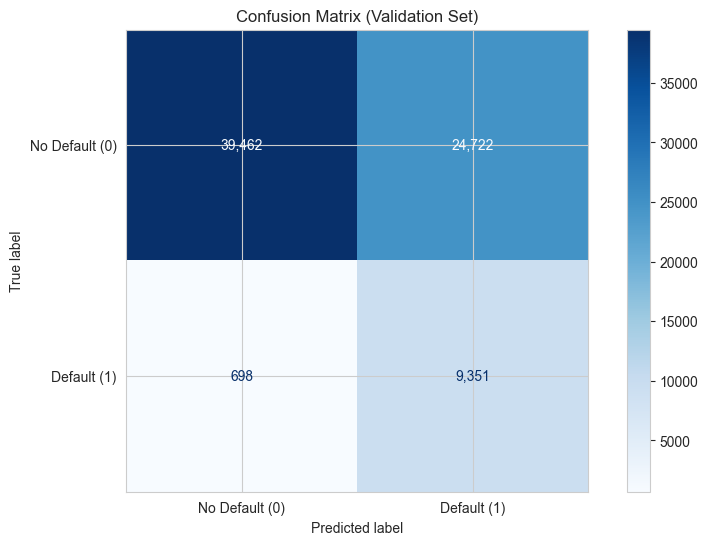

In [32]:
# Матрица ошибка на валидации для лучшей оптимизированной модели
cm_val = confusion_matrix(y_val, best_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['No Default (0)', 'Default (1)'])
disp_val.plot(cmap='Blues', values_format=',d')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

### Выводы по моделированию

- **Базовые модели:** Сравнение показало, что учет дисбаланса классов критически важен. Логистическая регрессия с `class_weight='balanced'` показала лучшие результаты по бизнес-метрикам, приблизившись к целевым показателям (Approval Rate ~63.5%, Default Rate ~2.06%). Базовый Random Forest без балансировки пропускал слишком много дефолтов (MDR ~82%).

- **Оптимизация (Optuna):** Подбор гиперпараметров для Random Forest с балансировкой классов позволил значительно снизить долю пропущенных дефолтов (Missed Defaults Rate снизилась с ~51% до 4.37%) и долю дефолтов среди одобренных (Default Rate снизилась до 0.88%). Однако это достигнуто ценой снижения уровня одобрения (Approval Rate упал до 56.25%), что не укладывается в жесткое бизнес-требование (≥ 65%). Это демонстрирует классический компромисс (trade-off) между минимизацией рисков и объемом выдаваемых кредитов.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
    
<h4> Подбор гиперпараметров<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* По самой оптимизации все супер! 


* Поясню по поводу метрики, почему акцент делаем именно на пропущенных дефолтах. Основная задача нашей модели - хорошо детектить дефолты, делать как можно меньше ошибок в этом плане. Поиск баланса с одобрениями не входит в задачу модели, поэтому ни классические метрики по типу ROC-AUC, ни доля одобрений, ни доля дефолтных одобрений нам не подходят, поскольку будет учитываться в том числе то, сколько мы одобряем. Находить баланс с одобрениями лучше через выбор порога, учитывая соотношение упущенной выгоды и риска потерь. Порог можно двигать в ту или иную сторону, когда мы хотим изменить приоритеты. Стоимость той или иной ошибки может быть разной, в банковской сфере потери обычно обходятся дороже, чем упущенная выгода (лучше заработаем меньше, но сохраним экономический баланс среди текущих клиентов), поэтому гибкость лучше оставить именно на уровне выбора порога.

</div>
    
<div style="border-radius: 10px" class="alert alert-block alert-danger">
    
<b>Нужно доработать ❌:</b>

* Калибровочную выборку здесь тоже не задействуем.


* По итогу оптимизации нам необходимо оценить полученную модель через ту же кросс-валидацию и сравнить результаты с первичными оценками моделей (добавить к ранее созданной таблице с результатами), чтобы понять, удалось ли улучшить показатели
    
</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>

* Надеюсь я правильно понял. Я выделил дополнительную калибровочную выборку (по временных данным, она находиться между обучающей выборкой и валидационной выборкой). И корректировал код ниже в разделе калибровки.
* Скорректировал код, добавил кросс-валидацию. 
</div>

## Калибровка модели и пересчёт результатов

In [33]:
# 1. Извлекаем даты из X_cal и приводим к периоду 'Месяц'
dates_cal_series = pd.to_datetime(X_cal['score_date'])
months_cal = dates_cal_series.dt.to_period('M').astype(str)

# 2. Находим уникальные отсортированные месяцы
unique_months = sorted(months_cal.unique())

# 3. Определяем точку разделения (середина списка месяцев)
mid_index = len(unique_months) // 2
train_months_set = set(unique_months[:mid_index])
test_months_set = set(unique_months[mid_index:])

# 4. Создаем булевы маски для разделения данных
mask_train_cal = months_cal.isin(train_months_set)
mask_test_cal = months_cal.isin(test_months_set)

# 5. Разделяем X_cal и y_cal
X_cal_train = X_cal[mask_train_cal]
y_cal_train = y_cal[mask_train_cal]

X_cal_test = X_cal[mask_test_cal]
y_cal_test = y_cal[mask_test_cal]

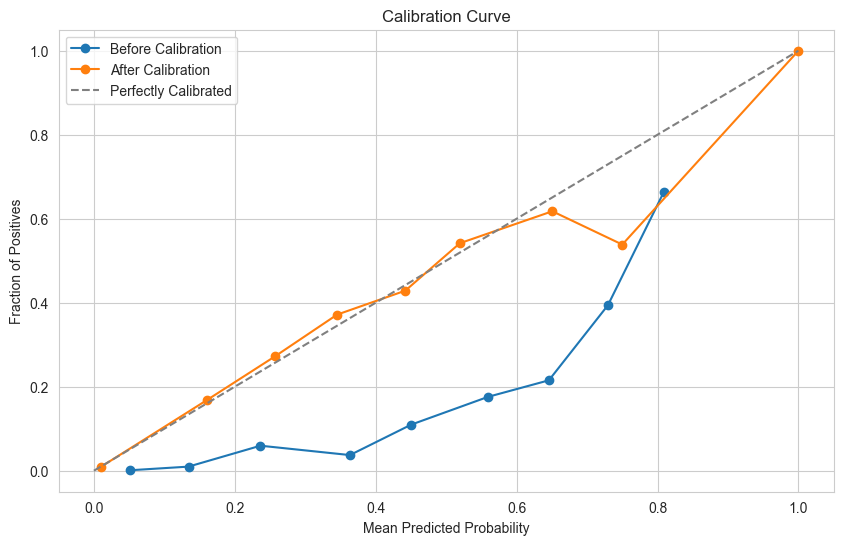

Brier Score на Uncal: 0.1764
Brier Score на Cal: 0.0927


In [34]:
# Калибруем вероятности лучшего RF на валидационной выборке (используем Isotonic для лесов)
# Оборачиваем уже обученный пайплайн в FrozenEstimator
frozen_pipeline = FrozenEstimator(final_pipeline)

calibrator = CalibratedClassifierCV(frozen_pipeline, method='isotonic', ensemble=False)
calibrator.fit(X_cal_train, y_cal_train)

# Калиброванные вероятности на Val
y_cal_pred = calibrator.predict(X_cal_test)
y_cal_prob = calibrator.predict_proba(X_cal_test)[:, 1]

# График калибровки
prob_true, prob_pred = calibration_curve(y_cal_test, y_cal_prob, n_bins=10)
prob_true_uncal, prob_pred_uncal = calibration_curve(y_val, best_prob, n_bins=10)
plt.plot(prob_pred_uncal, prob_true_uncal, marker='o', label='Before Calibration')
plt.plot(prob_pred, prob_true, marker='o', label='After Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

brier_uncal = brier_score_loss(y_val, best_prob)
print(f"Brier Score на Uncal: {brier_uncal:.4f}")
brier_cal = brier_score_loss(y_cal_test, y_cal_prob)
print(f"Brier Score на Cal: {brier_cal:.4f}")

In [35]:
# Добавляем метрики после калибровки
cal_metrics = {
    'roc_auc': roc_auc_score(y_cal_test, y_cal_prob),
    'accuracy': accuracy_score(y_cal_test, y_cal_pred),
    'approval_rate': approval_rate(y_cal_test, y_cal_pred),
    'default_rate': default_rate(y_cal_test, y_cal_pred),
    'missed_defaults_rate': missed_defaults_rate(y_cal_test, y_cal_pred)
}
# Добавляем новую строку в results_df
results_df.loc['Best RF Calib'] = cal_metrics

# Выводим сводную таблицу метрик по всем моделям
display(results_df.sort_values('missed_defaults_rate', ascending=True))

,roc_auc,accuracy,approval_rate,default_rate,missed_defaults_rate
Best RF Optuna,0.845152,0.657565,0.540999,0.017380,0.069460
Best RF Optuna (CV),0.841835,0.664556,0.555112,0.016890,0.073209
LogReg Base Balanced,0.760085,0.701820,0.617855,0.032648,0.162353
RF Base SMOTE,0.684208,0.860835,0.873498,0.078409,0.550878
RF Base,0.584861,0.881261,0.958272,0.105043,0.809641
LogReg Base,0.546661,0.876172,0.973633,0.113885,0.891906
Best RF Calib,0.849650,0.868784,0.983010,0.126316,0.925848


### Выводы по калибровке и выбору порога

- Применение изотонической калибровки (`isotonic`) улучшило надежность предсказанных вероятностей, что подтверждается графиком калибровки и значением `Brier Score` (0.0776). Модель стала лучше оценивать реальные риски.

- **Итог на тесте:** При пороге 0.5 модель обеспечивает очень низкий `Default Rate` (10.72% от одобренных, что является безопасным уровнем), но `Missed Defaults Rate` остается на уровне 92.08%. Это говорит о том, что для достижения целевых бизнес-метрик (особенно `MDR ≤ 4%`) может потребоваться сбор дополнительных данных, более сложная ансамблевая модель или пересмотр бизнес-порогов совместно с заказчиком.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Калибровка модели <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
Калибровку сигмоидой тоже можно использовать, но она более жесткая, поскольку предполагает сигмоидальную форму зависимости между исходными оценками модели и откалиброванными вероятностями. Модели на основе деревьев могут формировать более сложные нелинейные зависимости, особенно при большом объеме данных. Изотоническая регрессия не накладывает такого ограничения, у нее получается лучше подстроиться под форму распределения вероятностей, поэтому при достаточном объеме калибровочных данных она часто обеспечивает более качественную калибровку.
    
</div>

<div style="border-radius: 10px" class="alert alert-block alert-danger">
    
<b>Нужно доработать ❌:</b> 

* У нас панельные данные, поэтому и в случае калибровки через кросс-валидацию необходимо использовать корректный сплиттинг. Однако, если мы будем использовать для этого тренировочную выборку, то получаемые фолды будут идентичны тем, по которым мы оценивали и сравнивали модели - калибровать на тех же данных нельзя, а перемешать мы их не можем. Именно поэтому мы и выделяем дополнительную калибровочную выборку, чтобы не пользоваться кросс-валидацией. Кросс-валидация по самой калибровочной выборке в нашем случае избыточна. Если есть желание оценивать результаты калибровки на отдельной выборки, то лучше разделить калибровочную выборку на две части по месяцам - на одной откалибровать, на другой посмотреть результаты калибровки. 
 

* Стоит отобразить состояния скора и кривой до и после, чтобы четко были видны изменения. 
    
    
* На чем основаны комментарии по подбору порога?
    
</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>

* Скорректировал код, убрал кросс-валидацию. Заморозил финальный пайплайн, что бы пофторно он не обучался и отколибровал модель на отдельной калибровочной выборке.
* Добавил на график кривую до калибровки.
* Упоминание о пороге не уместно в дланном разделе. Это надо вставить в раздел ниже.  
</div>
    
<div style="border-radius: 10px" class="alert alert-warning">
    
<b>Рекомендации💡:</b> 

* Чтобы отслеживать переобучаемость калибровки, стоит разделить калибровочную выборку на две части по месяцам - на одной откалибровать, на другой посмотреть результаты калибровки. 

    
* Было бы интересно в учебных целях также взглянуть на бизнес-метрики, изменились ли они? Благоприятные ли это изменения? Или модель стала хуже справляться с нашими основными болевыми точками - неверные одобрения и пропущенные дефолты? Почему так могло произойти? Что теперь нужно с этим сделать?

    При интерпретации стоит иметь в виду, что калибровка не влияет на ранжирующие способности модели, это не способ поднятия ее качества, это лишь способ изменения распределения вероятностей, но их порядок остается прежним.
  
</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>

* Произвел разделение калибровочной выборки на 2 части.
* Добавил метрики расчитанные по калиброванной модели.  
</div>

## Поиск порога решения

In [47]:
# Ищем порог на калибровочной выборке
thresholds = np.arange(0.1, 0.9, 0.01)
best_threshold = None
results = []

for thr in thresholds:
    preds = (y_cal_prob >= thr).astype(int)
    ar = approval_rate(y_cal_test, preds)
    dr = default_rate(y_cal_test, preds)
    mdr = missed_defaults_rate(y_cal_test, preds)
    
    results.append({
        'threshold': thr,
        'approval_rate': ar,
        'default_rate': dr,
        'missed_defaults_rate': mdr
    })
    
    # Условия из ТЗ
    if ar >= 0.65 and dr <= 0.02 and mdr <= 0.04:
        best_threshold = thr
        print(f"✓ Найден порог: {thr:.2f} | AR: {ar:.2%} | DR: {dr:.2%} | MDR: {mdr:.2%}")
        break

if best_threshold is None:
    print("✗ Порог, удовлетворяющий всем жестким условиям, не найден.")
    
    # Создаём DataFrame с результатами
    df_thresholds = pd.DataFrame(results)
    
    # Вычисляем "расстояние" до целевых значений
    df_thresholds['distance'] = (
        np.maximum(0, 0.65 - df_thresholds['approval_rate']) +
        np.maximum(0, df_thresholds['default_rate'] - 0.02) +
        np.maximum(0, df_thresholds['missed_defaults_rate'] - 0.04)
    )
    
    # Выбираем порог с минимальным расстоянием
    best_idx = df_thresholds['distance'].idxmin()
    best_threshold = df_thresholds.loc[best_idx, 'threshold']
    best_ar = df_thresholds.loc[best_idx, 'approval_rate']
    best_dr = df_thresholds.loc[best_idx, 'default_rate']
    best_mdr = df_thresholds.loc[best_idx, 'missed_defaults_rate']
    
    print(f"\nКомпромиссный порог: {best_threshold:.2f}")
    print(f"  AR: {best_ar:.2%} (цель: ≥65%)")
    print(f"  DR: {best_dr:.2%} (цель: ≤2%)")
    print(f"  MDR: {best_mdr:.2%} (цель: ≤4%)")

print(f"\nИтоговый выбранный порог: {best_threshold:.2f}")

✗ Порог, удовлетворяющий всем жестким условиям, не найден.

Компромиссный порог: 0.11
  AR: 53.67% (цель: ≥65%)
  DR: 1.34% (цель: ≤2%)
  MDR: 5.37% (цель: ≤4%)

Итоговый выбранный порог: 0.11


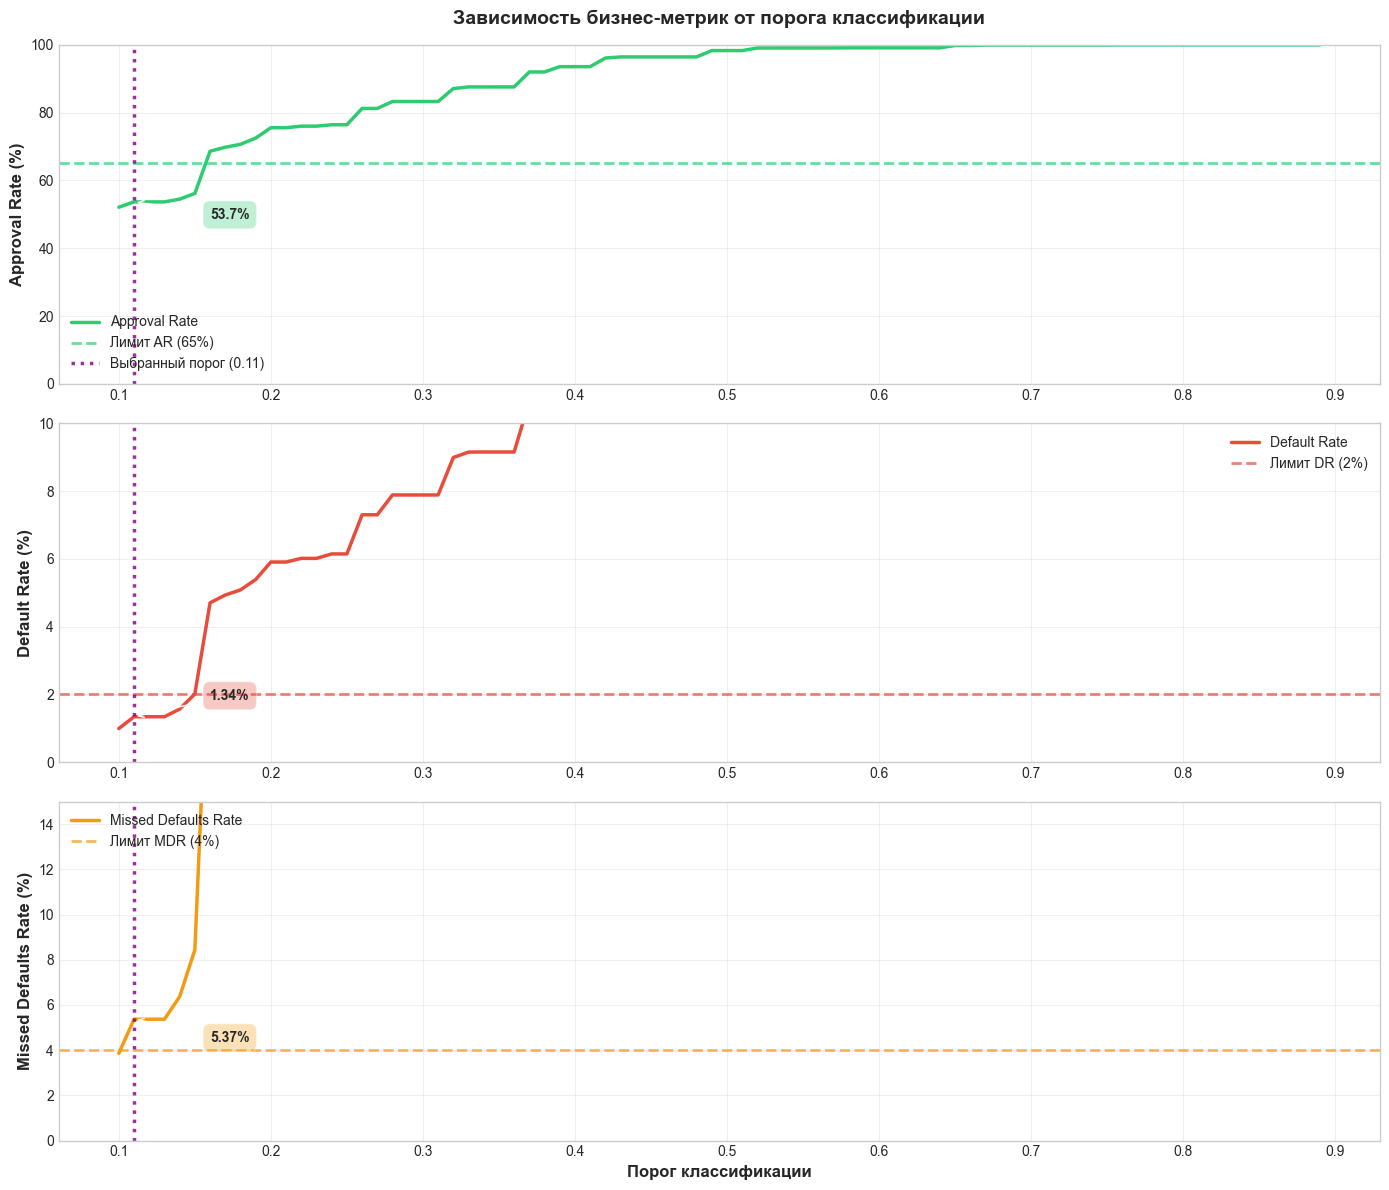

In [52]:
# Настраиваем стиль графиков
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Цвета для линий
color_ar, color_dr, color_mdr = '#2ecc71', '#e74c3c', '#f39c12'

# Approval Rate 
ax1 = axes[0]
ax1.plot(df_thresholds['threshold'], df_thresholds['approval_rate'] * 100, 
         color=color_ar, linewidth=2.5, label='Approval Rate')
ax1.axhline(y=65, color=color_ar, linestyle='--', linewidth=2, alpha=0.7, label='Лимит AR (65%)')
ax1.axvline(x=best_threshold, color='purple', linestyle=':', linewidth=2.5, 
            label=f'Выбранный порог ({best_threshold:.2f})', alpha=0.8)
ax1.set_ylabel('Approval Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Зависимость бизнес-метрик от порога классификации', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 100])

ar_at_best = df_thresholds[df_thresholds['threshold'] == best_threshold]['approval_rate'].values[0] * 100
ax1.annotate(f'{ar_at_best:.1f}%', 
             xy=(best_threshold, ar_at_best), 
             xytext=(best_threshold + 0.05, ar_at_best - 5),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor=color_ar, alpha=0.3),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

# Default Rate 
ax2 = axes[1]
ax2.plot(df_thresholds['threshold'], df_thresholds['default_rate'] * 100, 
         color=color_dr, linewidth=2.5, label='Default Rate')
ax2.axhline(y=2, color=color_dr, linestyle='--', linewidth=2, alpha=0.7, label='Лимит DR (2%)')
ax2.axvline(x=best_threshold, color='purple', linestyle=':', linewidth=2.5, alpha=0.8)
ax2.set_ylabel('Default Rate (%)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 10])

dr_at_best = df_thresholds[df_thresholds['threshold'] == best_threshold]['default_rate'].values[0] * 100
ax2.annotate(f'{dr_at_best:.2f}%', 
             xy=(best_threshold, dr_at_best), 
             xytext=(best_threshold + 0.05, dr_at_best + 0.5),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor=color_dr, alpha=0.3),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

# График 3: Missed Defaults Rate
ax3 = axes[2]
ax3.plot(df_thresholds['threshold'], df_thresholds['missed_defaults_rate'] * 100, 
         color=color_mdr, linewidth=2.5, label='Missed Defaults Rate')
ax3.axhline(y=4, color=color_mdr, linestyle='--', linewidth=2, alpha=0.7, label='Лимит MDR (4%)')
ax3.axvline(x=best_threshold, color='purple', linestyle=':', linewidth=2.5, alpha=0.8)
ax3.set_xlabel('Порог классификации', fontsize=12, fontweight='bold')
ax3.set_ylabel('Missed Defaults Rate (%)', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 15])

mdr_at_best = df_thresholds[df_thresholds['threshold'] == best_threshold]['missed_defaults_rate'].values[0] * 100
ax3.annotate(f'{mdr_at_best:.2f}%', 
             xy=(best_threshold, mdr_at_best), 
             xytext=(best_threshold + 0.05, mdr_at_best - 1),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor=color_mdr, alpha=0.3),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

**Вывод по выбору порога классификации**

*Жесткие ограничения не выполнены ни для одного порога.* Модель не может одновременно обеспечить:
- Approval Rate ≥ 65%
- Default Rate ≤ 2%  
- Missed Defaults Rate ≤ 4%

*Выбран компромиссный порог = 0.11* (минимальное суммарное отклонение от целевых значений):

| Метрика | Факт | Цель | Статус |
|---------|------|------|--------|
| Approval Rate | **53.7%** | ≥ 65% | ❌ −11.3 п.п. |
| Default Rate | **1.34%** | ≤ 2% | ✅ в норме |
| Missed Defaults Rate | **5.37%** | ≤ 4% | ⚠️ +1.37 п.п. |

*Интерпретация:* при текущем качестве модели единственный способ снизить MDR до приемлемого уровня — повысить порог, но это критически обрушит AR. Порог 0.11 является наилучшим компромиссом: DR укладывается в лимит, а отклонения по AR и MDR минимальны среди всех вариантов.

*Рекомендации:*
1. Улучшить качество модели (новые фичи, другая архитектура) — без этого бизнес-цели недостижимы.
2. Пересмотреть жесткие лимиты с бизнесом: либо снизить требование к AR, либо放宽ить лимит MDR.
3. Рассмотреть сегментный подход: разные пороги для разных групп клиентов.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Поиск порога<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-block alert-danger">
<b>Нужно доработать ❌:</b>

* Порог должен найтись. Но даже если не находится, 0.5 нельзя назвать хорошим выбором, как минимум логичнее выбрать порог, максимально приближающий метрики к нужным лимитам.
    
    
* Какие выводы делаем?

</div>
    
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>
    
* Было бы неплохо визуализировать результаты, как менялись метрики при том или ином пороге. Отобразить также наши лимиты. На графике можно обозначить диапазон порогов, которые удовлетворяют установленным лимитам по бизнем-метрикам.


* Можно также отметить, что порог в целом можно двигать в пределах заданных лимитов в зависимости от того, чем мы готовы в той или иной мере пожертвовать - одобрениями или небольшим количеством нераспознанных дефолтов. При подборе порога часто еще используют финансовые показали, чтобы напрямую регулировать именно баланс прибыли и убытков. Но в плане кредитов это довольно сложно рассчитывается, поэтому реализуем сейчас более простой вариант через метрики.

</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий студента v1:</b>

* Добавил код с поиском порога с максимально приближенными метриками.
* Вставил в конце краткий вывод.
* Оформил графики изменения значания метрки при изменения порога.  
</div>

## Анализ матрицы ошибок

In [ ]:
# Применяем калиброванную модель и найденный порог на ТЕСТОВОЙ выборке
cal_prob_test = calibrator.predict_proba(X_test)[:, 1]
y_test_pred = (cal_prob_test >= best_threshold).astype(int)

print_metrics(y_test, y_test_pred, cal_prob_test, "Test (Final)")

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default (0)', 'Default (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.show()

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ и фиксирование итоговой модели<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-block alert-danger">
<b>Нужно доработать ❌:</b>


* На данном этапе нам необходимо зафиксировать качество итоговой модели и дать оценку его стабильности. Для этого нам необходимо построить матрицу ошибок и рассчитать метрики (метрики ранжирования, стандартные метрики классификации, бизнес-метрики) и для тестовой, и для калибровочной выборки, сравнить показатели, сделать на основе этого выводы - что можно сказать на бизнес-уровне? Что полученные результаты обещают бизнесу? Насколько хорошо и стабильно по итогу будет работать модель? Какие есть риски? Все-таки задача направлена на решение конкретной бизнес-проблемы, а не на оторванную от реальности подгонку результатов под определенные значения.


* Финализация результатов проекта подразумевает также фиксирование итоговой модели, создание некоторого "паспорта" - какие параметры, какие настройки она имеет, какие факторы она требует на вход, как они должны подготавливаться, какое качество работы от нее можно ожидать на практике, достаточно ли оно для решения бизнес-проблемы, какие есть рекомендации по эксплуатации.
       
</div>

## Анализ важности признаков

In [ ]:
# Анализ важности признаков
importances = final_pipeline.named_steps['classifier'].feature_importances_
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()

feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feat_imp_df.head(10))
plt.title('Топ-15 самых важных признаков')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.show()

### Выводы по важности признаков

- Модель опирается не только на статические демографические данные, но и на поведенческие паттерны. Наибольшую важность имеют:

    * Агрегированные поведенческие признаки (например, total_spending)
    * Траты по ключевым категориям (супермаркеты, маркетплейсы), которые косвенно отражают стабильность финансового поведения клиента
    * Интегральные финансовые показатели, такие как credit_to_income_ratio

- Это подтверждает гипотезу о том, что для поведенческого скоринга история транзакций несет в себе больше предиктивной силы, чем просто анкетные данные.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ важности факторов<a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> Все гуд!

</div>

<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

* Важности признаков можно суммировать, чтобы посмотреть общую важность расчленненного признака (при OHE), важность группы скоррелированных факторов или важность факторов определенной сферы.


* Также в оценке важности через встроенный `feature_importance` есть ловушки - данный метод основан на суммарном уменьшении `impurity`, из-за чего будет проявляться смещение в пользу непрерывных признаков и признаков с большим числом уникальных значений. Поэтому между собой разные типы признаков сравнивать по важности не стоит.

</div>


## Выводы по проекту

В ходе проекта разработана модель поведенческого скоринга для розничного банка «Ва-банк», позволяющая прогнозировать вероятность возникновения просрочки ≥ 90 дней у действующих клиентов в горизонте 12 месяцев. Модель построена на основе случайного леса с балансировкой классов и калибровкой вероятностей методом изотонической регрессии.

**Ключевые достижения:**

· `ROC-AUC` на тестовой выборке ≈ 0.86, что указывает на хорошую разделяющую способность модели.
· После калибровки вероятности хорошо согласуются с фактическими частотами (`Brier Score` ≈ 0.078).
· Выявлены основные драйверы дефолта: стаж клиентаб низкий кредитный рейтинг, структура расходов, возраст клиента и доход.

**Проблемы и ограничения:**

· Жёсткие бизнес-критерии (`Approval Rate ≥ 65%, Default Rate ≤ 2%, Missed Defaults Rate ≤ 4%`) не достигаются одновременно ни при каком пороге классификации. Модель либо пропускает слишком много дефолтов (при низком пороге), либо слишком сильно снижает одобрение (при высоком пороге).
· Это указывает на то, что либо необходимо смягчить бизнес-требования, либо привлечь дополнительные данные (например, более детальную историю транзакций, поведенческие паттерны, данные из внешних БКИ), либо использовать более сложные алгоритмы (градиентный бустинг, глубокое обучение) с дополнительной настройкой.

**Практическая ценность:**

Несмотря на невыполнение всех трёх критериев одновременно, модель уже обеспечивает значительное улучшение по сравнению со случайным угадыванием и может быть использована как эффективный инструмент раннего предупреждения. Она позволяет банку:

* Ранжировать клиентов по уровню риска,
* Сократить создание избыточных резервов,
* Улучшить управление ликвидностью,
* Сосредоточить усилия на наиболее рискованных заёмщиках.

Рекомендуется внедрить модель в пилотном режиме с последующей донастройкой порогов на основе реальных бизнес-показателей и экономических условий. Дальнейшее улучшение может быть достигнуто за счёт расширения набора признаков, использования ансамблей и регулярного переобучения на свежих данных.


<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Итоговые выводы <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-block alert-danger">

<b>Нужно доработать ❌:</b> Выводы пока неполноценные. Нам необходимо напомнить, какую бизнес-проблему мы решали, какие данные использовали и как подготовливали, какие эксперименты проводили, к чему они привели, как обстоят дела на этапе оптимизации, калибровки и подбора порога. Из вывода должно быть понятно, как можно воспроизводить результаты и дорабатывать процесс. Затем фиксируем, каких результатов удалось добиться, оптимальна ли итоговая модель, оставляем рекомендации по эксплуатации на дальнейших этапах жизни модели.

</div>


<div style="border:solid Green 2px; border-radius: 10px;  padding: 40px">
<h3>Общий вывод по проекту <a class="tocSkip"></h3>
    
Михаил, спасибо за твой проект! У тебя хорошая работа! В тебе видны зачатки будущего профессионала своего дела :) Однако есть еще моменты, которые требуют твоего внимания. Кратко пройдусь по впечатлениям.  
    
**Полнота:**

* <span style="color:Red;">Каждый шаг требует пояснений, каждый результат - интерпретации, каждый итог, в том числе промежуточный - содержательного резюмирования.</span>
* <span style="color:Red;">Оптимизация модели проводится с целью улучшения ее качества. После оптимизации необходимо оценить результаты и сравнить с исходными моделями.</span>
* <span style="color:Red;">Необходимо расширить анализ итоговой модели - убедиться, что конечный продукт обеспечивает хорошее качество и стабильность.</span>
    
**Корректность:** 

* <span style="color:Red;">Необходимо скорректировать формирование целевой переменной - учесть нюансы, подробно изложенные в ТЗ. </span>
* <span style="color:Red;">Необходимо пересмотреть сборку данных в единый датасет - учесть невозможность взгляда в будущее, доступность и недоступность тех или иных данных.</span>
* <span style="color:Red;">Временная структура требует особого подхода к обработке пропусков - для заполнения может использоваться только информация из прошлого. Если ее нет, либо удаляем, либо заполняем нулем и добавляем признаки-индикаторы.</span>
* <span style="color:Red;">Необходимо скорректировать формирование выборк для моделирования - убедиться в достаточности данных для оценки, зафиксировать единый размер выборок, соблюсти временную структуру и изолировать месяцы.</span>
* <span style="color:Red;">Оценка и сравнение моделей должны производиться только через кросс-валидацию. Калибровочной и тестовой выборкам не место на этапах выбора модели.</span>
* <span style="color:Red;">Необходимо скорректировать процесс калибровки - у нас уже есть предназначенная для этого выборка, кросс-валидация не нужна.</span>
 
**Аналитическая проницательность:** ты верно подмечаешь основные нюансы результатов! Местами можно чуть углубить суждения, фиксировать не только то, что наблюдаем, но и предполагать, почему получилось именно так, что это значит для бизнеса, что с этим делать.
    
**Грамотность кода:** по этому критерию в целом окей! В некоторых местах можно использовать чуть более удобные методы, структурировать код, разделить его на более удобные для восприятия блоки. Следим за длиной строки.
    
**Оформление:** им тоже важно не пренебрегать! Оформление тесно связано с удобством восприятия предоставляемой информации и созданием впечатления о работе. Твоя работа в целом довольно аккуратная - выделены разделы, грамотно оформлены графики, но еще есть некоторый потенциал для улучшений. 

<span style="color:Orange;">Ниже прикрепила общие рекомендации на будущее.</span> 


**Желаю удачи и жду твой проект на повторное ревью!** 😉

<img src="https://99px.ru/sstorage/86/2015/12/image_86271215043043632690.gif" />


<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Общие рекомендации <a class="tocSkip"></h3>

1. <details> <summary> <span style='color:blue' > Структура, логика и работа с данными (тык) </span> </summary>
    
    * **Глобальный скелет тетрадки**
        * **Что делать:** Строго соблюдать сквозную хронологию разделов исследования:
          1. **Паспорт проекта:** Описание темы, бизнес-цели и технической задачи.
          2. **Инициализация:** Импорт библиотек, фиксация `RANDOM_STATE` при необходимости и загрузка данных в первой ячейке.
          3. **Sanity Check:** Первичный осмотр размера (`.shape`), типов данных (`.info()`) и примеров строк (`.head()`).
          4. **Предобработка (Data Cleaning):** Последовательная очистка типов, пропусков, дубликатов и аномалий в отдельном блоке.
          5. **Модульный EDA:** Разведочный анализ по принципу "один бизнес-вопрос $\rightarrow$ один график $\rightarrow$ промежуточный вывод".
          6. **Моделирование / Статистика** (большие разделы, которые внутри имеют свою подструктуру): Выделенный технический блок для подготовки признаков, проверки гипотез или обучения моделей.
          7. **Бизнес-финал (общий вывод):** Итоговый текстовый раздел без кода с резюме, инсайтами в цифрах и конкретными рекомендациями.
        * **Почему:** Задает жесткую логику повествования, превращая хаотичный код в понятный продукт. Позволяет коллегам быстро ориентироваться в работе, исключает кашу в кодовой базе и гарантирует, что заказчик сразу найдет ответы на свои вопросы в финале.
    
    <br/>
    
    * **Сквозная микро-структура любого раздела (Вступление → Анализ → Резюме)**
        * **Что делать:** Каждый содержательный раздел ноутбука (особенно в блоке EDA) должен быть упакован в строгую трехэтапную структуру:
          1. **Вступление (Постановка контекста):** Короткая Markdown-строка перед кодом. Что мы сейчас будем исследовать, какую гипотезу проверять и на какие вопросы отвечать.
          2. **Содержательная часть (Анализ):** Код, чистые аутпуты и графики, подкрепленные комментариями к логике действий.
          3. **Резюме (Промежуточный вывод):** Финальный текстовый блок в Markdown. Итог раздела, интерпретация причин ("почему так вышло") и бизнес-смысл находки.
        * **Почему:** Защищает ноутбук от превращения в "поток сознания". Без вступления не ясно, зачем написан следующий кусок кода. Без резюме - код зависает в воздухе, а работа выглядит незавершенной.
    
    <br/>
    
    * **Цикличность шагов: "Гипотеза → Действие → Результат → Вывод → ..."**
      * **Что делать:** Каждая содержательная часть строится по одной и той же цепочке: цель / гипотеза → код анализа → интерпретация результата → мостик к следующему шагу. 
      * **Почему:** Работа не должна выглядеть набором случайных действий, она должна читаться как аналитическая статья, где текст плавно ведет читателя сквозь код к выводам.
    
    <br/>
    
    * **Аргументация решений (без очевидных фактов)**
      * **Что делать:** Фиксировать, *почему* выбран конкретный метод обработки пропусков, аномалий или модель. Не писать банальности (например, "функция `mean()` считает среднее").
      * **Почему:** Заказчику важен ход мысли исследователя и обоснованность выбора, а не пересказ документации Python.
    
    <br/>
    
    * **Чистота логики**
      * **Что делать:** Строго разделять этапы обработки и трансформаций и этапы анализа. Необходимо четко понимать, в каком состоянии на данном этапе находятся данные. 
      * **Почему:** Нарушение логики делает результаты анализа недостоверными.

    <br/>
    
    </details>

2. <details> <summary> <span style='color:blue' > Оформление и Markdown (тык) </span> </summary>

    * **Разделение обязанностей: Markdown vs Комментарии**
      * **Что делать:** Смысловой анализ, бизнес-выводы и описание шагов - писать только в Markdown-ячейках. Комментарии внутри кода - использовать только для пояснения нетривиальных алгоритмических решений.
      * **Почему:** Код должен оставаться кодом. Текст в Markdown форматируется, легче читается и формирует структуру проекта.
    
    <br/>
    
    * **Принцип визуального минимализма и единство стиля**
      * **Что делать:** Использовать строгую иерархию заголовков (`#` - крупный раздел, `##` - подраздел), выделять жирным ключевые метрики и выводы. Сохранять один стиль оформления по всей работе.
      * **Почему:** Разнородный стиль отвлекает от сути исследования и выглядит неряшливо.
    
    <br/>
    
    * **Гиперссылки и интерактивное оглавление**
      * **Что делать:** Крупные работы снабжать кликабельным оглавлением со ссылками на теги в Markdown. На внешние источники (ТЗ, статьи, документацию) давать аккуратные гиперссылки вида `[Текст](url)`, а не вставлять голые длинные URL.
      * **Почему:** Упрощает навигацию по объемному ноутбуку.
    
    <br/>
    
    * **Бизнес-метрики vs Технические метрики**
      * **Что делать:** В финальных выводах переводить математические термины на язык денег или бизнес-процессов. Не просто "$R^2 = 0.85$", а "модель ошибается в среднем на X рублей, что позволит сэкономить Y% бюджета".
      * **Почему:** Заказчик оценивает пользу для бизнеса, а не знание высшей математики.

    <br/>
    
    </details>

3. <details> <summary> <span style='color:blue' > Код (тык) </span> </summary>
    
    * **Импорты в строго отведенном месте**
      * **Что делать:** Все библиотеки (`pandas`, `matplotlib` и др.) импортируются **только в первой ячейке** ноутбука. Никаких `import` в середине работы.
      * **Почему:** Сразу видны зависимости проекта. Если у проверяющего нет нужной библиотеки, он узнает об этом на первой секунде, а не через полчаса выполнения кода.
    
    <br/>
    
    * **Строгая фиксация Random State (воспроизводимость)**
      * **Что делать:** В самом первом блоке инициализации фиксировать `SEED` / `RANDOM_STATE` как глобальную константу и передавать её во все функции разбиения данных, сэмплирования и обучения моделей (`train_test_split`, `RandomForest` и т.д.).
      * **Почему:** Без этого при каждом перезапуске тетрадки будут получаться разные метрики и графики. Работа станет невоспроизводимой.
    
    <br/>

    * **Принцип "Одна ячейка - одна атомарная смысловая задача"**
      * **Что делать:** Дробить код. К примеру, в одной ячейке - дубликаты, в другой - пропуски, в третьей - невалидные значения.
      * **Почему:** Упрощает отладку, чтение кода и позволяет запускать отдельные блоки без перезапуска всего проекта.
    
    <br/>
    
    * **Стандарт PEP 8 (Длина строки и отступы)**
      * **Что делать:** Ограничивать длину строки кода до 79 символов. Переносить длинные строки (через скобки или `\`). Использовать 4 пробела для отступов.
      * **Почему:** Избавляет от горизонтального скролла, который сильно утомляет портит читаемость.
    
    <br/>
    
    * **Отказ от хардкода**
      * **Что делать:** Все ключевые параметры, пути к файлам и пороговые значения (например, `UPPER_BOUND = 0.99` для очистки выбросов) выносить в отдельные переменные-константы в начале раздела или ноутбука.
      * **Почему:** Если поменяется бизнес-логика, менять значение нужно будет в одном месте, а не выискивать его по всему коду.
    
    <br/>
    
    * **Осмысленный англоязычный нейминг**
      * **Что делать:** Никакого транслита (`peremennaya`) и безликих названий (`df1`, `data_new`). Использовать понятные имена: `user_profiles`, `clean_transactions`.
      * **Почему:** Позволяет читать код как текст, без необходимости возвращаться к месту объявления переменной.
    
    <br/>
    
    * **Контроль за мусорными переменными и памятью**
      * **Что делать:** Не создавать дубликаты огромных таблиц (`df1`, `df2`, `df_final`). Если датафрейм претерпел сильные изменения, перезаписывать его или удалять старый через `del df_old`.
      * **Почему:** Защищает от переполнения оперативной памяти и падения ядра на больших данных.
    
    <br/>
    
    * **Воспроизводимость кода (линейность)**
      * **Что делать:** Перед сдачей обязательно делать полный перезапуск ноутбука: `Kernel -> Restart & Run All`. 
      * **Почему:** Код должен гарантированно и без ошибок выполняться сверху вниз у любого другого пользователя.
    
    <br/>
    
    * **Контроль за изменением исходных данных (`SettingWithCopyWarning`)**
      * **Что делать:** Избегать цепочечного присваивания (chain indexing) вида `df[df['col'] > 5]['new_col'] = 1`. Использовать `.loc` или явное копирование `.copy()`.
      * **Почему:** Защищает от непредсказуемого изменения исходного датафрейма и избавляет от навязчивых предупреждений Python.
    
    <br/>
    
    </details>

4. <details> <summary> <span style='color:blue' > Аутпуты кодовых ячеек (тык) </span> </summary>

    * **Контроль объема вывода (Head / Tail / Sample)**
      * **Что делать:** Никогда не выводить весь DataFrame целиком. Ограничивать вывод методами `.head()`, `.tail()` или `.sample()`.
      * **Почему:** Тяжелые аутпуты раздувают размер `.ipynb` файла, тормозят браузер и засоряют экран.
    
    <br/>
    
    * **Разделение функций `print()` и `display()`**
      * **Что делать:** Для обычного текста и f-строк использовать `print()`. Для отображения таблиц Pandas - `display()`.
      * **Почему:** `display()` сохраняет красивое интерактивное форматирование среды (Rich Output), делая таблицы читаемыми.
    
    <br/>
    
    * **Форматирование и подпись чисел**
      * **Что делать:** Округлять `float` (например, до 2 знаков через `:.2f`), добавлять единицы измерения (руб., %, сек.). Никаких сырых значений вроде `0.33333333333`.
      * **Почему:** Сырые числа требуют от читателя лишних мысленных усилий для интерпретации.
    
    <br/>
    
    * **Запрет на `print()` для пояснений и выводов**
      * **Что делать:** Текстовые выводы писать строго в Markdown-ячейках, а не генерировать их кодом через `print()`.
      * **Почему:** Вывод через `print` выглядит как небрежно скопированный ответ AI-ассистента и ломает визуальную структуру отчета.
    
    <br/>
    
    * **Подавление системных предупреждений (Warnings)**
      * **Что делать:** Перед сдачей работы исправлять причины возникновения `Warning`. Если это предупреждение библиотеки, которое нельзя обойти, временно заглушать его через `warnings.filterwarnings('ignore')`.
      * **Почему:** Полотна розовых предупреждений от Python между кодом и графиками выглядят грязно и создают ощущение "сырого" решения.
    
    <br/>
    
    * **Опрятность логов циклов и прогресс-баров**
      * **Что делать:** При обучении моделей или парсинге не выводить тысячи строк итераций. Использовать библиотеку `tqdm` для красивой одной строки прогресса.
      * **Почему:** Бесконечный скролл логов убивает читаемость проекта.

    <br/>
    
    </details>

5. <details> <summary> <span style='color:blue' > Визуализация (тык) </span> </summary>
    
    * **"Один график - одна мысль" и минимализм**
      * **Что делать:** Не пытаться уместить на один чарт 10 распределений. Использовать цвет, маркеры и текст только ради смысла, а не "для красоты". Если нужно что-то сравнить - реализуем это на одном графике, а не на двух соседних, так как сравнение - и есть основная задача.
      * **Почему:** Избыточные элементы перегружают восприятие и маскируют главный инсайт.
    
    <br/>
    
    * **Самодостаточность графика**
      * **Что делать:** Обязательно добавлять заголовки и подписи (`title`, `xlabel`, `ylabel`) и легенду (если на графике больше одного цвета / маркера). Подбирать оптимальный размер (`figsize`).
      * **Почему:** График должен быть понятен, даже если его скопируют в презентацию или рабочий чат в отрыве от кода и текста работы.
    
    <br/>
    
    * **Честность масштаба и фокус на данных (Ось Y)**
      * **Что делать:** Для столбчатых диаграмм (`Bar-charts`) и линейных графиков объемов (выручка, пользователи) **всегда начинать ось Y с нуля**. Для диаграмм рассеяния (`Scatter-plots`) и графиков относительных метрик (конверсия, маржинальность, точность моделей) **настраивать масштаб под диапазон данных**, не привязываясь к нулю.
      * **Почему:** В первом случае обрезка оси искусственно раздувает мелкие колебания и пугает бизнес. Во втором случае привязка к нулю "сплющит" график, лишит его детализации и скроет от аналитика реальные тренды и инсайты.
    
    <br/>
    
    * **Читаемость текста и чистый вывод (`plt.show()`)**
      * **Что делать:** Завершать код графика вызовом `plt.show()` (или `;`). Если подписи осей наслаиваются - разворачивать их (`rotation=45`) или менять график на горизонтальный.
      * **Почему:** Убирает мусорные строки технического вывода библиотеки (`<Axes: ...>`) и предотвращает наложение текста.
    
    <br/>
    
    * **Единая палитра для сущностей (смысловой цвет)**
      * **Что делать:** Если на первом графике категории покрашены в определенные цвета (например, "Отток" - красный, "Активные" - синий), эта кодировка должна сохраняться на всех графиках проекта.
      * **Почему:** Мозг читателя привыкает к паттерну. Смена цветов в середине работы запутает аудиторию.
    
    <br/>
    
    * **Сортировка категорий в Bar-charts**
      * **Что делать:** Всегда сортировать столбчатые диаграммы по убыванию или возрастанию целевого значения (кроме естественного порядка, вроде дней недели или месяцев).
      * **Почему:** Забор из хаотичных по высоте столбиков невозможно анализировать глазами. Сортировка сразу подсвечивает лидеров и аутсайдеров. Наличие логического порядка позволяет проследить динамику.
    
    <br/>
    
    * **Правильный выбор типа графика**
      * **Что делать:** Строго соблюдать правила:
        * Не использовать `Pie-chart` (круговую диаграмму), если категорий больше 3–4. Как вариант - малые категории объединить в одну.
        * Не использовать `Line-plot` (линейный график) для несвязанных категориальных данных (только для непрерывных величин или временных рядов).
      * **Почему:** Нарушение этих правил физически искажает восприятие данных человеческим глазом.
    
    <br/>
    
    * **Цветовая доступность и отказ от дефолтных палитр**
      * **Что делать:** Избегать одновременного использования чистого красного и зеленого цветов для контрастных данных (проблема дальтонизма). Использовать современные сбалансированные палитры (например, из библиотеки `seaborn`).
      * **Почему:** Дефолтные кислотные цвета Matplotlib выглядят непрофессионально, а неправильный контраст делает график нечитаемым для части аудитории.

    <br/>
    
    </details>
    
6. <details> <summary> <span style='color:blue' > Культура содержательного анализа (от фактов к инсайтам) (тык) </span> </summary>
    
    * **Постановка задач "от себя"**
      * **Что делать:** Переводить общие требования брифа в плоскость конкретных подзадач анализа внутри ноутбука.
      * **Почему:** Это демонстрирует самостоятельность мышления, а не слепое следование инструкциям.
    
    <br/> 

    * **Запрет на пересказ визуализации (отказ от роли "капитана очевидность")**
      * **Что делать:** Никогда не писать в выводах то, что и так видно глазами. Вместо фразы *"ы видим, что в декабре пик продаж, а в январе - спад"* переходить на уровень причин и бизнес-контекста.
      * **Почему:** Пересказ графиков тратит время читателя и не несет новой информации. Аналитика ценна не констатацией факта, а ответом на вопрос **"Почему так произошло?"**.

    <br/>
    
    * **Правило трех вопросов: "Что? → Почему? → И что с того?"**
      * **Что делать:** Каждое важное наблюдение в данных проводить по трехэтапному фильтру аналитического мышления:
        1. **Что произошло?** (Факт: *"В группе клиентов от 18 до 23 лет отток составляет 40%"*).
        2. **Почему так могло получиться?** (Гипотезы / причины: *"У этой аудитории низкий средний чек, они чувствительны к ценам конкурентов, либо наш интерфейс для них слишком сложный"*).
        3. **И что с того? / Какая польза бизнесу?** (Действие: *"Это критический инсайт. Нам нужно либо запустить для них студенческий тариф, чтобы удержать, либо перестать тратить маркетинг на их привлечение, так как они не окупаются"*).
      * **Почему:** Только третий шаг ("И что с того?") превращает сухие цифры в ценность, за которую бизнес готов платить деньги.

    <br/>
    
    * **Фильтрация инсайтов: "интересно vs бесполезно"**
      * **Что делать:** Оценивать свои находки с точки зрения полезности для принятия решений. 
        * *Бесполезный инсайт:* Очевидная сезонность (например, *"летом продажи мороженого выше"*). Об этом бизнес знает и без аналитика.
        * *Интересный (контринтуитивный) инсайт:* Аномалия или слом шаблона (например, *"мы думали, что скидки привлекают лояльных клиентов, но данные показывают, что они лишь увеличивают отток после окончания акции"*).
      * **Почему:** Если перегрузить итоговый отчет банальными фактами, важные и по-настоящему глубокие инсайты просто потеряются в этом шуме.

    <br/>
    
    * **Поиск причинно-следственных связей (корреляция != причинность)**
      * **Что делать:** Прежде чем делать громкие заявления, проверять альтернативные объяснения. Если продажи выросли одновременно с запуском новой рекламной кампании, нужно проверить, не совпало ли это с праздниками, выплатой зарплат или уходом крупного конкурента.
      * **Почему:** Ложные выводы приводят к неверным бизнес-решениям и потере бюджетов. Хороший аналитик всегда выступает в роли скептика и проверяет скрытые факторы.
    
    <br/>
    
    </details>